In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
machines = pd.read_csv("../data/PdM_machines.csv")

In [3]:
machines.head()

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


In [4]:
machines["model"].value_counts()

model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

In [5]:
machines.shape

(100, 3)

In [6]:
machines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   machineID  100 non-null    int64 
 1   model      100 non-null    object
 2   age        100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [7]:
machines.isnull().sum()

machineID    0
model        0
age          0
dtype: int64

In [8]:
machines.duplicated().sum()

np.int64(0)

In [9]:
telemetry = pd.read_csv("../data/PdM_telemetry.csv")

In [10]:
telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [11]:
telemetry.shape

(876100, 6)

In [12]:
telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  object 
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ MB


In [13]:
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])

In [14]:
telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[ns]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 40.1 MB


In [15]:
telemetry.isnull().sum()

datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

In [16]:
telemetry.duplicated().sum()

np.int64(0)

In [17]:
telemetry.describe()

,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 18:00:00,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


In [18]:
telemetry["machineID"].nunique()

100

In [19]:
telemetry["machineID"].value_counts().sort_index()

machineID
1      8761
2      8761
3      8761
4      8761
5      8761
       ... 
96     8761
97     8761
98     8761
99     8761
100    8761
Name: count, Length: 100, dtype: int64

In [20]:
machine_1 = telemetry[telemetry["machineID"] == 1]
machine_1.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


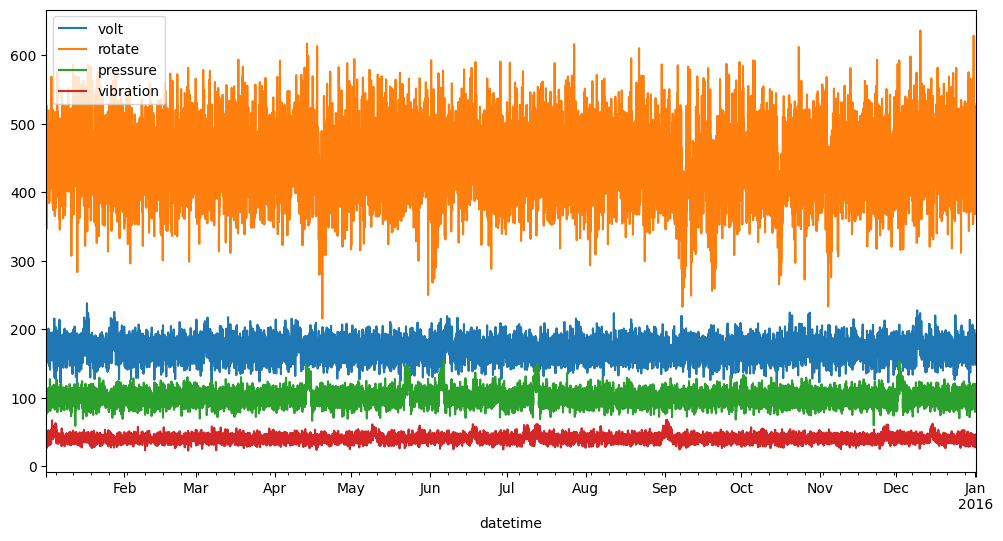

In [21]:
machine_1.plot(
    x="datetime",
    y=["volt", "rotate", "pressure", "vibration"],
    figsize=(12, 6)
)
plt.show()

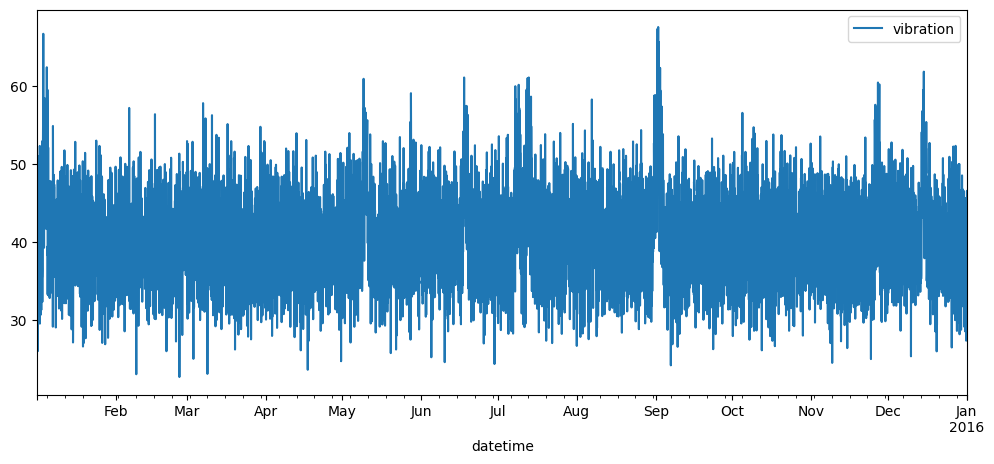

In [22]:
machine_1.plot(
    x="datetime",
    y="vibration",
    figsize=(12, 5)
)
plt.show()

In [23]:
machine_1["vibration"].agg(["mean", "max"])

mean    40.586309
max     67.633435
Name: vibration, dtype: float64

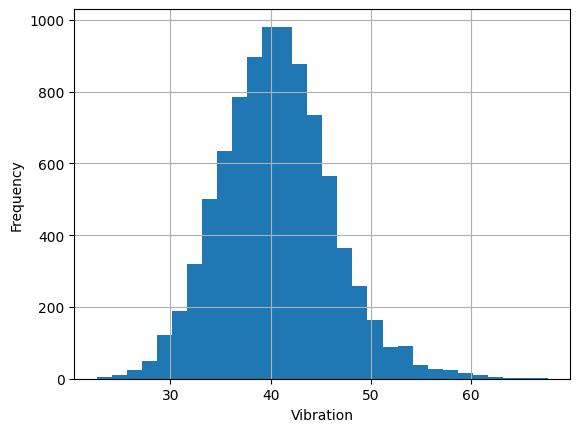

In [24]:
machine_1["vibration"].hist(bins=30)
plt.xlabel("Vibration")
plt.ylabel("Frequency")
plt.show()

In [25]:
machine_1["vibration"].describe()

count    8761.000000
mean       40.586309
std         5.542143
min        22.666865
25%        36.847203
50%        40.417442
75%        44.004311
max        67.633435
Name: vibration, dtype: float64

In [26]:
telemetry.columns

Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration'], dtype='object')

In [27]:
sensor_columns = ["volt", "rotate", "pressure", "vibration"]
telemetry[sensor_columns].corr()

,volt,rotate,pressure,vibration
volt,1.000000,-0.001511,0.001652,0.002390
rotate,-0.001511,1.000000,-0.000688,-0.003056
pressure,0.001652,-0.000688,1.000000,0.001395
vibration,0.002390,-0.003056,0.001395,1.000000


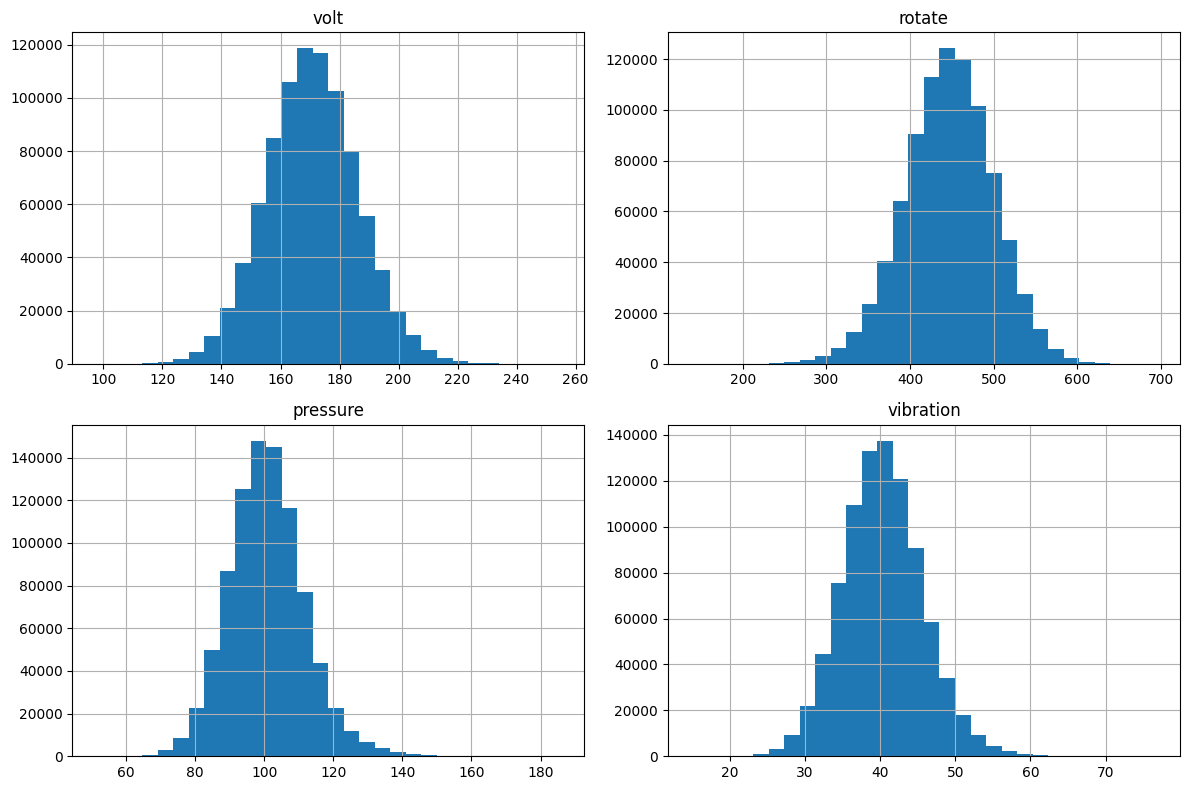

In [28]:
telemetry[sensor_columns].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [29]:
failures = pd.read_csv("../data/PdM_failures.csv")

print("Shape:", failures.shape)

print("\nColumns:")
print(failures.columns)

print("\nInfo:")
failures.info()

print("\nFirst 5 rows:")
display(failures.head())

print("\nNull values:")
print(failures.isnull().sum())

print("\nDuplicate rows:")
print(failures.duplicated().sum())

print("\nFailure types:")
print(failures["failure"].value_counts())

print("\nMachines with failures:")
print(failures["machineID"].nunique())

Shape: (761, 3)

Columns:
Index(['datetime', 'machineID', 'failure'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   761 non-null    object
 1   machineID  761 non-null    int64 
 2   failure    761 non-null    object
dtypes: int64(1), object(2)
memory usage: 18.0+ KB

First 5 rows:


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4



Null values:
datetime     0
machineID    0
failure      0
dtype: int64

Duplicate rows:
0

Failure types:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

Machines with failures:
98


In [30]:
failures["datetime"] = pd.to_datetime(failures["datetime"])

failures = failures.sort_values(
    by=["machineID", "datetime"]
).reset_index(drop=True)

print(failures["datetime"].dtype)

display(failures.head(10))

datetime64[ns]


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4
5,2015-10-17 06:00:00,1,comp2
6,2015-12-16 06:00:00,1,comp4
7,2015-03-19 06:00:00,2,comp1
8,2015-03-19 06:00:00,2,comp2
9,2015-04-18 06:00:00,2,comp2


In [31]:
errors = pd.read_csv("../data/PdM_errors.csv")

print("Shape:", errors.shape)

print("\nColumns:")
print(errors.columns)

print("\nFirst 5 rows:")
display(errors.head())

print("\nNull values:")
print(errors.isnull().sum())

print("\nDuplicate rows:")
print(errors.duplicated().sum())

print("\nUnique machines with errors:")
print(errors["machineID"].nunique())

print("\nError types:")
print(errors["errorID"].value_counts())

print("\nDatetime datatype:")
print(errors["datetime"].dtype)

Shape: (3919, 3)

Columns:
Index(['datetime', 'machineID', 'errorID'], dtype='object')

First 5 rows:


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4



Null values:
datetime     0
machineID    0
errorID      0
dtype: int64

Duplicate rows:
0

Unique machines with errors:
100

Error types:
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

Datetime datatype:
object


In [32]:
errors["datetime"] = pd.to_datetime(errors["datetime"])

errors = errors.sort_values(
    by=["machineID", "datetime"]
).reset_index(drop=True)

print(errors["datetime"].dtype)

display(errors.head(10))

datetime64[ns]


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4
5,2015-01-25 15:00:00,1,error4
6,2015-01-27 04:00:00,1,error1
7,2015-03-03 22:00:00,1,error2
8,2015-03-05 06:00:00,1,error1
9,2015-03-20 18:00:00,1,error1


In [33]:
maint = pd.read_csv("../data/PdM_maint.csv")

print("Shape:", maint.shape)

print("\nColumns:")
print(maint.columns)

print("\nFirst 5 rows:")
display(maint.head())

print("\nNull values:")
print(maint.isnull().sum())

print("\nDuplicate rows:")
print(maint.duplicated().sum())

print("\nUnique machines:")
print(maint["machineID"].nunique())

print("\nMaintenance types:")
print(maint["comp"].value_counts())

print("\nDatetime datatype:")
print(maint["datetime"].dtype)

Shape: (3286, 3)

Columns:
Index(['datetime', 'machineID', 'comp'], dtype='object')

First 5 rows:


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4



Null values:
datetime     0
machineID    0
comp         0
dtype: int64

Duplicate rows:
0

Unique machines:
100

Maintenance types:
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64

Datetime datatype:
object


In [34]:
maint["datetime"] = pd.to_datetime(maint["datetime"])

maint = maint.sort_values(
    by=["machineID", "datetime"]
).reset_index(drop=True)

print(maint["datetime"].dtype)

display(maint.head(10))

datetime64[ns]


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4
5,2015-01-05 06:00:00,1,comp1
6,2015-01-20 06:00:00,1,comp3
7,2015-01-20 06:00:00,1,comp1
8,2015-02-04 06:00:00,1,comp4
9,2015-02-04 06:00:00,1,comp3


In [35]:
print(machines.columns)

display(machines.head())

print("\nMachine models:")
print(machines["model"].value_counts())

print("\nMachine age statistics:")
print(machines["age"].describe())

Index(['machineID', 'model', 'age'], dtype='object')


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2



Machine models:
model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

Machine age statistics:
count    100.000000
mean      11.330000
std        5.856974
min        0.000000
25%        6.750000
50%       12.000000
75%       16.000000
max       20.000000
Name: age, dtype: float64


In [36]:
telemetry = telemetry.merge(
    machines[["machineID", "age"]],
    on="machineID",
    how="left",
    validate="many_to_one"
)

telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18


In [37]:
# Work on a copy; the existing age merge is reused.
df = telemetry.copy()
if "age" not in df.columns:
    df = df.merge(
        machines[["machineID", "age"]],
        on="machineID",
        how="left",
        validate="many_to_one"
    )

# Process whole arrays per machine, rather than looping over telemetry rows.
error_counts = np.zeros(len(df), dtype=int)
maintenance_hours = np.full(len(df), np.nan)
failure_labels = np.zeros(len(df), dtype=int)
window = np.timedelta64(24, "h")

for machine_id, positions in df.groupby("machineID").indices.items():
    times = df.iloc[positions]["datetime"].to_numpy(dtype="datetime64[ns]")
    error_times = errors.loc[
        errors["machineID"] == machine_id, "datetime"
    ].to_numpy(dtype="datetime64[ns]")
    maintenance_times = maint.loc[
        maint["machineID"] == machine_id, "datetime"
    ].to_numpy(dtype="datetime64[ns]")
    failure_times = failures.loc[
        failures["machineID"] == machine_id, "datetime"
    ].to_numpy(dtype="datetime64[ns]")

    # Event tables were already sorted in the existing cells.
    for event_times in (error_times, maintenance_times, failure_times):
        assert not np.isnat(event_times).any()
        assert (event_times[:-1] <= event_times[1:]).all()
    assert not np.isnat(times).any()

    # Count every error in (time - 24 hours, time], including simultaneous errors.
    start = np.searchsorted(error_times, times - window, side="right")
    end = np.searchsorted(error_times, times, side="right")
    error_counts[positions] = end - start
    has_errors = end > start
    assert (error_times[start[has_errors]] > times[has_errors] - window).all()
    assert (error_times[end[has_errors] - 1] <= times[has_errors]).all()

    # The last maintenance at or before the reading; no history stays NaN.
    previous = np.searchsorted(maintenance_times, times, side="right") - 1
    has_maintenance = previous >= 0
    last_maintenance = maintenance_times[previous[has_maintenance]]
    assert (last_maintenance <= times[has_maintenance]).all()
    maintenance_hours[positions[has_maintenance]] = (
        (times[has_maintenance] - last_maintenance) / np.timedelta64(1, "h")
    )

    # Look forward only for the target: time < failure <= time + 24 hours.
    following = np.searchsorted(failure_times, times, side="right")
    has_future_failure = following < len(failure_times)
    next_failure = failure_times[following[has_future_failure]]
    assert (next_failure > times[has_future_failure]).all()
    failure_labels[positions[has_future_failure]] = (
        next_failure <= times[has_future_failure] + window
    ).astype(int)

df["errors_last_24h"] = error_counts
df["hours_since_last_maintenance"] = maintenance_hours
df["failure_next_24h"] = failure_labels

In [38]:
# Confirm that integration preserved the readings and their order.
assert len(df) == len(telemetry), "Telemetry row count changed"
if not telemetry.duplicated(["machineID", "datetime"]).any():
    assert not df.duplicated(["machineID", "datetime"]).any()

original_columns = telemetry.columns.tolist()
pd.testing.assert_frame_equal(
    df[original_columns].reset_index(drop=True),
    telemetry.reset_index(drop=True)
)
assert df["failure_next_24h"].isin([0, 1]).all()
assert (df["errors_last_24h"] >= 0).all()
assert (df["hours_since_last_maintenance"].dropna() >= 0).all()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
print("\nNull values:")
print(df.isnull().sum())
print("\nFailure target counts:")
print(df["failure_next_24h"].value_counts().sort_index())
print("\nHistorical feature statistics:")
display(df[["errors_last_24h", "hours_since_last_maintenance"]].describe())
print("Validation passed: row count, unique keys, original values, and time boundaries.")

Shape: (876100, 10)
Columns: ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'age', 'errors_last_24h', 'hours_since_last_maintenance', 'failure_next_24h']


,datetime,machineID,volt,rotate,pressure,vibration,age,errors_last_24h,hours_since_last_maintenance,failure_next_24h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,0,456.0,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,0,457.0,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,0,458.0,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,0,459.0,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,0,460.0,0



Null values:
datetime                        0
machineID                       0
volt                            0
rotate                          0
pressure                        0
vibration                       0
age                             0
errors_last_24h                 0
hours_since_last_maintenance    0
failure_next_24h                0
dtype: int64

Failure target counts:
failure_next_24h
0    858916
1     17184
Name: count, dtype: int64

Historical feature statistics:


,errors_last_24h,hours_since_last_maintenance
count,876100.000000,876100.000000
mean,0.107253,263.621687
std,0.353272,322.139335
min,0.000000,0.000000
25%,0.000000,102.000000
50%,0.000000,205.000000
75%,0.000000,309.000000
max,4.000000,4079.000000


Validation passed: row count, unique keys, original values, and time boundaries.


In [39]:
# Row-based rolling/shift features require chronological, hourly machine history.
df = df.sort_values(["machineID", "datetime"]).reset_index(drop=True)
if df["datetime"].isna().any() or df.duplicated(["machineID", "datetime"]).any():
    raise ValueError("Telemetry requires unique, non-missing machine timestamps.")
if not df.groupby("machineID")["datetime"].diff().dropna().eq(pd.Timedelta(hours=1)).all():
    raise ValueError("The trained 24-row/6-row features require hourly telemetry.")

df["vibration_24h_mean"] = (
    df.groupby("machineID")["vibration"]
      .transform(lambda x: x.rolling(window=24, min_periods=1).mean())
)

In [40]:
display(
    df[
        ["machineID", "datetime", "vibration", "vibration_24h_mean"]
    ].head(30)
)

,machineID,datetime,vibration,vibration_24h_mean
0,1,2015-01-01 06:00:00,45.087686,45.087686
1,1,2015-01-01 07:00:00,43.413973,44.250829
2,1,2015-01-01 08:00:00,34.178847,40.893502
3,1,2015-01-01 09:00:00,41.122144,40.950662
4,1,2015-01-01 10:00:00,25.990511,37.958632
5,1,2015-01-01 11:00:00,35.655017,37.574696
6,1,2015-01-01 12:00:00,42.753920,38.314585
7,1,2015-01-01 13:00:00,35.482009,37.960513
8,1,2015-01-01 14:00:00,45.482287,38.796266
9,1,2015-01-01 15:00:00,39.901735,38.906813


In [41]:
df["volt_24h_mean"] = (
    df.groupby("machineID")["volt"]
      .transform(lambda x: x.rolling(window=24, min_periods=1).mean())
)

df["rotate_24h_mean"] = (
    df.groupby("machineID")["rotate"]
      .transform(lambda x: x.rolling(window=24, min_periods=1).mean())
)

df["pressure_24h_mean"] = (
    df.groupby("machineID")["pressure"]
      .transform(lambda x: x.rolling(window=24, min_periods=1).mean())
)

display(
    df[
        [
            "machineID",
            "datetime",
            "volt_24h_mean",
            "rotate_24h_mean",
            "pressure_24h_mean",
        ]
    ].head(30)
)

,machineID,datetime,volt_24h_mean,rotate_24h_mean,pressure_24h_mean
0,1,2015-01-01 06:00:00,176.217853,418.504078,113.077935
1,1,2015-01-01 07:00:00,169.548538,410.625784,104.269230
2,1,2015-01-01 08:00:00,170.028993,449.533798,94.592122
3,1,2015-01-01 09:00:00,168.137453,423.687682,98.256232
4,1,2015-01-01 10:00:00,166.031967,426.025520,100.982315
5,1,2015-01-01 11:00:00,167.110779,426.741827,100.139769
6,1,2015-01-01 12:00:00,165.602958,437.074655,101.799186
7,1,2015-01-01 13:00:00,166.467935,433.643413,101.699423
8,1,2015-01-01 14:00:00,167.452001,429.755120,102.691083
9,1,2015-01-01 15:00:00,167.628643,432.864675,102.906797


In [42]:
df["volt_24h_std"] = (
    df.groupby("machineID")["volt"]
      .transform(lambda x: x.rolling(window=24, min_periods=1).std())
)

df["pressure_24h_std"] = (
    df.groupby("machineID")["pressure"]
      .transform(lambda x: x.rolling(window=24, min_periods=1).std())
)

df["rotate_24h_std"] = (
    df.groupby("machineID")["rotate"]
      .transform(lambda x: x.rolling(window=24, min_periods=1).std())
)

df["vibration_24h_std"] = (
    df.groupby("machineID")["vibration"]
      .transform(lambda x: x.rolling(window=24, min_periods=1).std())
)

In [43]:
df["vibration_vs_24h_mean"] = (
    df["vibration"] - df["vibration_24h_mean"]
)

df["rotate_vs_24h_mean"] = (
    df["rotate"] - df["rotate_24h_mean"]
)

df["pressure_vs_24h_mean"] = (
    df["pressure"] - df["pressure_24h_mean"]
)

df["volt_vs_24h_mean"] = (
    df["volt"] - df["volt_24h_mean"]
)

In [44]:
df["vibration_6h_change"] = (
    df.groupby("machineID")["vibration"]
      .transform(lambda x: x - x.shift(6))
)

df["rotate_6h_change"] = (
    df.groupby("machineID")["rotate"]
      .transform(lambda x: x - x.shift(6))
)

df["pressure_6h_change"] = (
    df.groupby("machineID")["pressure"]
      .transform(lambda x: x - x.shift(6))
)

df["volt_6h_change"] = (
    df.groupby("machineID")["volt"]
      .transform(lambda x: x - x.shift(6))
)

In [45]:
cols_to_check = [
    "volt_24h_mean",
    "rotate_24h_mean",
    "pressure_24h_mean",
    "vibration_24h_mean",
    "volt_24h_std",
    "rotate_24h_std",
    "pressure_24h_std",
    "vibration_24h_std",
    "volt_6h_change",
    "rotate_6h_change",
    "pressure_6h_change",
    "vibration_6h_change"
]

print(df[cols_to_check].isnull().sum())

volt_24h_mean            0
rotate_24h_mean          0
pressure_24h_mean        0
vibration_24h_mean       0
volt_24h_std           100
rotate_24h_std         100
pressure_24h_std       100
vibration_24h_std      100
volt_6h_change         600
rotate_6h_change       600
pressure_6h_change     600
vibration_6h_change    600
dtype: int64


In [46]:
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,age,errors_last_24h,hours_since_last_maintenance,failure_next_24h,...,rotate_24h_std,vibration_24h_std,vibration_vs_24h_mean,rotate_vs_24h_mean,pressure_vs_24h_mean,volt_vs_24h_mean,vibration_6h_change,rotate_6h_change,pressure_6h_change,volt_6h_change
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,0,456.0,0,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,0,457.0,0,...,11.141591,1.183494,-0.836857,-7.878294,-8.808705,-6.669315,NaN,NaN,NaN,NaN
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,0,458.0,0,...,67.849599,5.874970,-6.714655,77.816028,-19.354217,0.960910,NaN,NaN,NaN,NaN
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,0,459.0,0,...,75.770259,4.798255,0.171482,-77.538347,10.992330,-5.674620,NaN,NaN,NaN,NaN
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,0,460.0,0,...,65.826868,7.875828,-11.968121,9.351353,10.904333,-8.421945,NaN,NaN,NaN,NaN


In [47]:
df["hours_since_last_maintenance"].isnull().sum()

np.int64(0)

In [48]:
df["hours_since_last_maintenance"].isnull().mean() * 100

np.float64(0.0)

In [49]:
df.columns

Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration',
       'age', 'errors_last_24h', 'hours_since_last_maintenance',
       'failure_next_24h', 'vibration_24h_mean', 'volt_24h_mean',
       'rotate_24h_mean', 'pressure_24h_mean', 'volt_24h_std',
       'pressure_24h_std', 'rotate_24h_std', 'vibration_24h_std',
       'vibration_vs_24h_mean', 'rotate_vs_24h_mean', 'pressure_vs_24h_mean',
       'volt_vs_24h_mean', 'vibration_6h_change', 'rotate_6h_change',
       'pressure_6h_change', 'volt_6h_change'],
      dtype='object')

In [50]:
columns_to_fill = [
    "volt_24h_std",
    "pressure_24h_std",
    "rotate_24h_std",
    "vibration_24h_std",

    "vibration_vs_24h_mean",
    "rotate_vs_24h_mean",
    "pressure_vs_24h_mean",
    "volt_vs_24h_mean",
    
    "vibration_6h_change",
    "rotate_6h_change",
    "pressure_6h_change",
    "volt_6h_change",
]

df[columns_to_fill] = df[columns_to_fill].fillna(0)

In [51]:
# Split whole machines: 70% train, 15% test, 15% validation.
from sklearn.model_selection import train_test_split

assert df["machineID"].notna().all(), "df contains missing machine IDs"

# Count failure records, NOT positive rows in failure_next_24h.
# Include every machine in df; machines absent from failures get zero.
machine_split = df[["machineID"]].drop_duplicates().sort_values("machineID").reset_index(drop=True)
machine_split["failure_count"] = (
    machine_split["machineID"].map(failures.groupby("machineID").size())
    .fillna(0).astype(int)
)

# Quantile bins keep equal failure counts in the same group.
# With the current data: low <= 6, medium 7-9, high >= 10.
machine_split["failure_group"], failure_bin_edges = pd.qcut(
    machine_split["failure_count"], q=3,
    labels=["low", "medium", "high"], retbins=True
)

train_machines, heldout_machines = train_test_split(
    machine_split, test_size=0.30, random_state=42,
    stratify=machine_split["failure_group"]
)
test_machines, validation_machines = train_test_split(
    heldout_machines, test_size=0.50, random_state=42,
    stratify=heldout_machines["failure_group"]
)

train_ids = set(train_machines["machineID"])
test_ids = set(test_machines["machineID"])
validation_ids = set(validation_machines["machineID"])

# Retain every row of an assigned machine in exactly one set.
train_df = df.loc[df["machineID"].isin(train_ids)].copy()
test_df = df.loc[df["machineID"].isin(test_ids)].copy()
validation_df = df.loc[df["machineID"].isin(validation_ids)].copy()

# Failure counts/groups are split metadata, not added as model features.
machine_split["split"] = machine_split["machineID"].map({
    **dict.fromkeys(train_ids, "train"),
    **dict.fromkeys(test_ids, "test"),
    **dict.fromkeys(validation_ids, "validation"),
})
assert train_ids.isdisjoint(test_ids)
assert train_ids.isdisjoint(validation_ids)
assert test_ids.isdisjoint(validation_ids)
assert train_ids | test_ids | validation_ids == set(df["machineID"])
assert len(train_df) + len(test_df) + len(validation_df) == len(df)

split_summary = pd.DataFrame({
    "machines": [len(train_ids), len(test_ids), len(validation_ids)],
    "rows": [len(train_df), len(test_df), len(validation_df)],
}, index=["train", "test", "validation"])
split_summary["machine_pct"] = 100 * split_summary["machines"] / len(machine_split)
split_summary["row_pct"] = 100 * split_summary["rows"] / len(df)
group_counts = pd.crosstab(machine_split["split"], machine_split["failure_group"]).reindex(
    index=split_summary.index, columns=["low", "medium", "high"], fill_value=0
)
group_percentages = group_counts.div(group_counts.sum(axis=1), axis=0) * 100
group_percentages.loc["overall"] = (
    machine_split["failure_group"].value_counts(normalize=True) * 100
)

print("Failure-count quantile edges:", failure_bin_edges)
display(machine_split.groupby("failure_group", observed=True)["failure_count"].agg(["min", "max", "count"]))
display(split_summary.round(2))
print("Machine counts per failure group:")
display(group_counts)
print("Failure-group percentages within each split:")
display(group_percentages.round(2))
print("Checks passed: no machine overlap; every df row is assigned exactly once.")
# Ratios target machines; row percentages can differ if machine sizes differ.


Failure-count quantile edges: [ 0.  6.  9. 19.]


,min,max,count
failure_group,,,
low,0,6,40
medium,7,9,32
high,10,19,28


,machines,rows,machine_pct,row_pct
train,70,613270,70.0,70.0
test,15,131415,15.0,15.0
validation,15,131415,15.0,15.0


Machine counts per failure group:


failure_group,low,medium,high
train,28,22,20
test,6,5,4
validation,6,5,4


Failure-group percentages within each split:


failure_group,low,medium,high
train,40.0,31.43,28.57
test,40.0,33.33,26.67
validation,40.0,33.33,26.67
overall,40.0,32.00,28.00


Checks passed: no machine overlap; every df row is assigned exactly once.


In [52]:
df["failure_next_24h"].value_counts()

failure_next_24h
0    858916
1     17184
Name: count, dtype: int64

In [53]:
# Prepare numerical features using the existing machine-wise splits.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, accuracy_score, average_precision_score,
)

target_column = "failure_next_24h"
excluded_columns = {
    "machineID", "datetime", target_column,
    "failure_count", "failure_group", "split",  # Split-only metadata.
}
# Frozen schema verified against the existing fitted SMOTE model and imputer.
feature_columns = [
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "age",
    "errors_last_24h",
    "hours_since_last_maintenance",
    "vibration_24h_mean",
    "volt_24h_mean",
    "rotate_24h_mean",
    "pressure_24h_mean",
    "volt_24h_std",
    "pressure_24h_std",
    "rotate_24h_std",
    "vibration_24h_std",
    "vibration_vs_24h_mean",
    "rotate_vs_24h_mean",
    "pressure_vs_24h_mean",
    "volt_vs_24h_mean",
    "vibration_6h_change",
    "rotate_6h_change",
    "pressure_6h_change",
    "volt_6h_change",
]
assert len(feature_columns) == len(set(feature_columns))
assert not set(feature_columns) & excluded_columns
assert set(feature_columns).issubset(train_df.columns)
# If rerun with fitted objects present, stop on schema drift before any fitting.
if "feature_imputer" in globals():
    assert list(feature_columns) == list(feature_imputer.feature_names_in_), "Fitted imputer schema mismatch"
if "smote_xgb" in globals():
    assert list(feature_columns) == list(smote_xgb.feature_names_in_), "Fitted model schema mismatch"
assert set(train_df.machineID).isdisjoint(validation_df.machineID)
assert set(train_df.machineID).isdisjoint(test_df.machineID)
assert set(validation_df.machineID).isdisjoint(test_df.machineID)

X_train = train_df.loc[:, feature_columns].copy().replace([np.inf, -np.inf], np.nan)
X_validation = validation_df.loc[:, feature_columns].copy().replace([np.inf, -np.inf], np.nan)
X_test = test_df.loc[:, feature_columns].copy().replace([np.inf, -np.inf], np.nan)
y_train = train_df[target_column].copy()
y_validation = validation_df[target_column].copy()
y_test = test_df[target_column].copy()
assert y_train.isin([0, 1]).all() and y_train.nunique() == 2
assert y_validation.isin([0, 1]).all() and y_validation.nunique() == 2

# Fit imputation only on training features; reuse it for both experiments.
# A training column with no observed values is consistently filled with zero.
feature_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
X_train = pd.DataFrame(
    feature_imputer.fit_transform(X_train), columns=feature_columns, index=X_train.index,
).astype("float32")
X_validation = pd.DataFrame(
    feature_imputer.transform(X_validation), columns=feature_columns, index=X_validation.index,
).astype("float32")
# X_test remains unprocessed until the selected-threshold evaluation cell.

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
baseline_xgb_params = dict(
    objective="binary:logistic", n_estimators=200, max_depth=4,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", eval_metric="aucpr", random_state=42,
    n_jobs=4, verbosity=0,
)

# Store threshold metrics silently; only confusion matrices are displayed below.
def threshold_results(y_true, probabilities, candidate_thresholds):
    pr_auc = average_precision_score(y_true, probabilities)
    records, matrices = [], {}
    for threshold in candidate_thresholds:
        predictions = (probabilities >= threshold).astype(int)
        matrices[threshold] = confusion_matrix(y_true, predictions, labels=[0, 1])
        records.append({
            "threshold": threshold,
            "precision": precision_score(y_true, predictions, zero_division=0),
            "recall": recall_score(y_true, predictions, zero_division=0),
            "f1": f1_score(y_true, predictions, zero_division=0),
            "accuracy": accuracy_score(y_true, predictions),
            "pr_auc": pr_auc,  # Average precision (not trapezoidal PR area).
        })
    return pd.DataFrame(records).set_index("threshold"), matrices


In [54]:
# Experiment 1: train weighted XGBoost only on the original training set.
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count
weighted_xgb = XGBClassifier(**baseline_xgb_params, scale_pos_weight=scale_pos_weight)
weighted_xgb.fit(X_train, y_train)

# Validation only: keep all thresholds available for your decision.
weighted_validation_probabilities = weighted_xgb.predict_proba(X_validation)[:, 1]
weighted_validation_metrics, weighted_validation_confusion_matrices = threshold_results(
    y_validation, weighted_validation_probabilities, thresholds,
)
weighted_validation_pr_auc = average_precision_score(y_validation, weighted_validation_probabilities)


In [55]:
# Experiment 2: SMOTE only on training data, followed by unweighted XGBoost.
# Standardize only for SMOTE's neighbour distances, then restore original units.
smote_scaler = StandardScaler()
X_train_for_smote = smote_scaler.fit_transform(X_train)
minority_count = int(y_train.value_counts().min())
assert minority_count >= 2, "SMOTE requires at least two minority-class training examples"
smote_sampler = SMOTE(random_state=42, k_neighbors=min(5, minority_count - 1))
X_train_resampled_scaled, y_train_smote = smote_sampler.fit_resample(X_train_for_smote, y_train)
X_train_smote = pd.DataFrame(
    smote_scaler.inverse_transform(X_train_resampled_scaled), columns=feature_columns,
).astype("float32")
smote_class_distribution = pd.DataFrame({
    "before_smote": y_train.value_counts().reindex([0, 1], fill_value=0),
    "after_smote": pd.Series(y_train_smote).value_counts().reindex([0, 1], fill_value=0),
}).rename(index={0: "No failure", 1: "Failure"})
del X_train_for_smote, X_train_resampled_scaled

smote_xgb = XGBClassifier(**baseline_xgb_params, scale_pos_weight=1.0)
smote_xgb.fit(X_train_smote, y_train_smote)
smote_validation_probabilities = smote_xgb.predict_proba(X_validation)[:, 1]
smote_validation_metrics, smote_validation_confusion_matrices = threshold_results(
    y_validation, smote_validation_probabilities, thresholds,
)
smote_validation_pr_auc = average_precision_score(y_validation, smote_validation_probabilities)


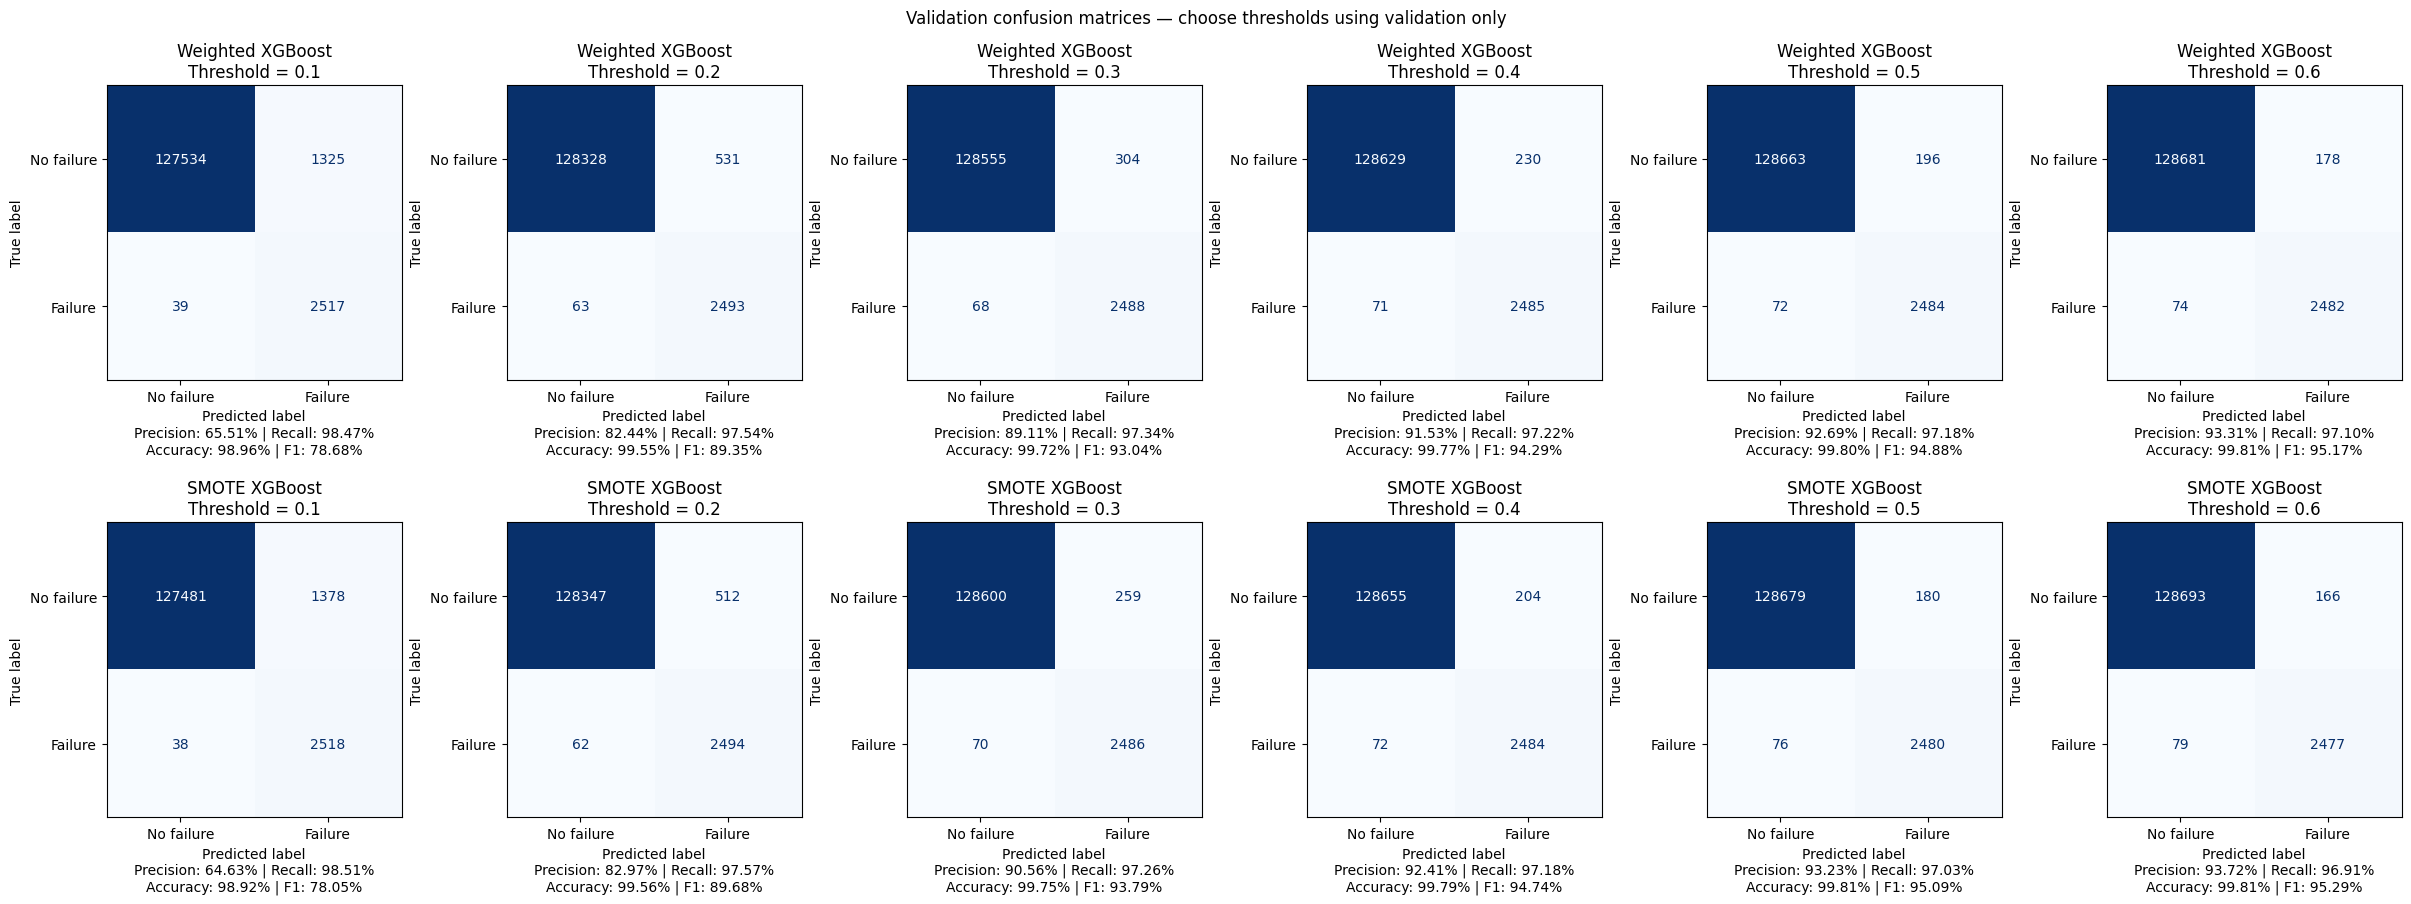

In [56]:
# Compare validation confusion matrices; rows = actual, columns = predicted.
# Optional details remain in validation_comparison and smote_class_distribution.
validation_comparison = pd.concat(
    {"Weighted XGBoost": weighted_validation_metrics, "SMOTE XGBoost": smote_validation_metrics},
    names=["experiment", "threshold"],
)
fig, axes = plt.subplots(2, len(thresholds), figsize=(24, 9), constrained_layout=True)
for row, (name, matrices) in enumerate([
    ("Weighted XGBoost", weighted_validation_confusion_matrices),
    ("SMOTE XGBoost", smote_validation_confusion_matrices),
]):
    for column, threshold in enumerate(thresholds):
        ConfusionMatrixDisplay(
            confusion_matrix=matrices[threshold], display_labels=["No failure", "Failure"],
        ).plot(ax=axes[row, column], colorbar=False, cmap="Blues", values_format="d")
        scores = validation_comparison.loc[(name, threshold)]
        axes[row, column].set_title(f"{name}\nThreshold = {threshold:.1f}")
        # Show failure-class precision/recall/F1 and overall accuracy below each matrix.
        axes[row, column].set_xlabel(
            "Predicted label\n"
            f"Precision: {scores['precision']:.2%} | Recall: {scores['recall']:.2%}\n"
            f"Accuracy: {scores['accuracy']:.2%} | F1: {scores['f1']:.2%}",
            fontsize=10,
        )
fig.suptitle("Validation confusion matrices — choose thresholds using validation only")
plt.show()


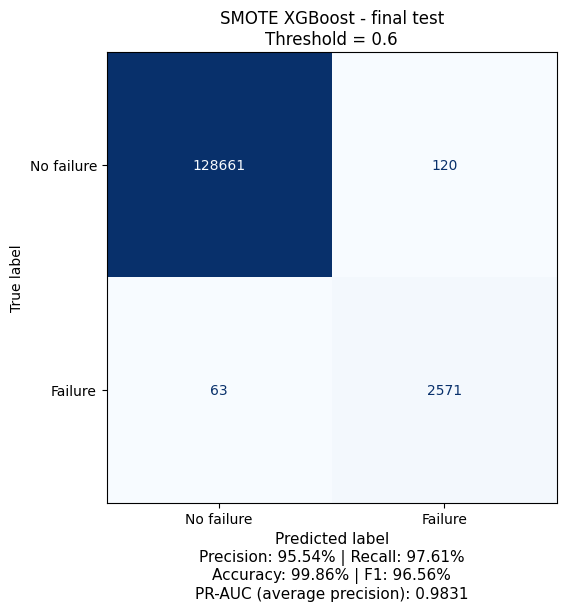

In [57]:
# Finalize SMOTE XGBoost at the user-selected 0.6 threshold; evaluate test once.
selected_smote_threshold = 0.6
assert y_test.isin([0, 1]).all() and y_test.nunique() == 2
X_test_imputed = pd.DataFrame(
    feature_imputer.transform(X_test), columns=feature_columns, index=X_test.index,
).astype("float32")
smote_test_probabilities = smote_xgb.predict_proba(X_test_imputed)[:, 1]
smote_test_metrics, smote_test_confusion_matrices = threshold_results(
    y_test, smote_test_probabilities, [selected_smote_threshold],
)
final_test_metrics = pd.concat(
    {"SMOTE XGBoost": smote_test_metrics}, names=["experiment", "threshold"],
)
final_test_confusion_matrices = {
    "SMOTE XGBoost": smote_test_confusion_matrices[selected_smote_threshold],
}

# Display the finalized model's confusion matrix and scores together.
scores = smote_test_metrics.loc[selected_smote_threshold]
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ConfusionMatrixDisplay(
    confusion_matrix=final_test_confusion_matrices["SMOTE XGBoost"],
    display_labels=["No failure", "Failure"],
).plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
ax.set_title(f"SMOTE XGBoost - final test\nThreshold = {selected_smote_threshold:g}")
ax.set_xlabel(
    "Predicted label\n"
    f"Precision: {scores['precision']:.2%} | Recall: {scores['recall']:.2%}\n"
    f"Accuracy: {scores['accuracy']:.2%} | F1: {scores['f1']:.2%}\n"
    f"PR-AUC (average precision): {scores['pr_auc']:.4f}",
    fontsize=11,
)
plt.show()


In [58]:
# Build one machine's hourly context and reuse the existing trained model.
def _machine_history_at(frame, machine_id, prediction_time, *, include_current=False):
    """Filter by machine first; interpret the dataset's naive timestamps as UTC."""
    selected = frame.loc[frame["machineID"] == machine_id].copy()
    selected["datetime"] = pd.to_datetime(selected["datetime"], utc=True, errors="raise")
    if selected["datetime"].isna().any():
        raise ValueError("Selected machine history contains missing timestamps.")
    cutoff = (selected["datetime"] <= prediction_time if include_current
              else selected["datetime"] < prediction_time)
    return selected.loc[cutoff].sort_values("datetime")


def _assert_failure_schema():
    assert list(feature_columns) == list(feature_imputer.feature_names_in_), "Imputer schema mismatch"
    assert list(feature_columns) == list(smote_xgb.feature_names_in_), "Model schema mismatch"
    assert len(feature_columns) == feature_imputer.n_features_in_ == smote_xgb.n_features_in_
    assert "machineID" not in feature_columns and "failure_next_24h" not in feature_columns


_assert_failure_schema()


def build_machine_features(machine_id, volt, rotate, pressure, vibration):
    """Public five-input builder; derive the selected machine's next hour internally."""
    machine_times = pd.to_datetime(
        telemetry.loc[telemetry["machineID"] == machine_id, "datetime"],
        utc=True, errors="raise",
    )
    if machine_times.empty or machine_times.isna().any():
        raise ValueError("Selected machine needs telemetry with valid timestamps.")
    timestamp = machine_times.max() + pd.Timedelta(hours=1)
    return _build_machine_features_at(
        machine_id, volt, rotate, pressure, vibration, prediction_time=timestamp,
    )


def _build_machine_features_at(machine_id, volt, rotate, pressure, vibration, *, prediction_time):
    """Internal historical/parity helper; history is strictly before the supplied hour.

    Training's 24-row window includes the current reading and up to 23 past hours.
    Initial standard deviation and unavailable 6-hour change match training's zero fill.
    """
    _assert_failure_schema()
    metadata = machines.loc[machines["machineID"] == machine_id]
    if len(metadata) != 1:
        raise ValueError(f"Expected one known machine record for machineID={machine_id!r}.")

    timestamp = pd.to_datetime(prediction_time, utc=True, errors="raise")
    if pd.isna(timestamp) or timestamp != timestamp.floor("h"):
        raise ValueError("Prediction timestamp must be a valid exact hour to match training.")

    sensors = ["volt", "rotate", "pressure", "vibration"]
    current = pd.Series([volt, rotate, pressure, vibration], index=sensors, dtype="float64")
    if not np.isfinite(current.to_numpy()).all():
        raise ValueError("All four current sensor values must be finite numbers.")

    # Protect rolling statistics and the model's float32 conversion from overflow.
    # This internal numerical safeguard is not a user-facing operating limit.
    numeric_limit = float(np.finfo(np.float32).max / 100)
    numerically_saturated = current.index[current.abs() > numeric_limit].tolist()
    current = current.clip(-numeric_limit, numeric_limit)

    age = float(metadata.iloc[0]["age"])
    if not np.isfinite(age):
        raise ValueError("Selected machine age is missing or invalid.")

    # Use only this machine's strictly earlier telemetry, including for historical tests.
    history = _machine_history_at(telemetry, machine_id, timestamp).tail(23)
    expected_hours = pd.date_range(end=timestamp - pd.Timedelta(hours=1), periods=len(history), freq="h")
    if not pd.DatetimeIndex(history["datetime"]).equals(expected_hours):
        raise ValueError(
            "Selected machine needs consecutive hourly telemetry ending one hour before prediction; "
            "history is duplicated or has gaps."
        )
    past_values = history[sensors].apply(pd.to_numeric, errors="raise")
    if not np.isfinite(past_values.to_numpy()).all():
        raise ValueError("Selected machine sensor history contains missing or non-finite readings.")
    window_values = pd.concat([past_values, current.to_frame().T], ignore_index=True)
    features = current.to_dict()
    features["age"] = age
    for sensor in sensors:
        mean = window_values[sensor].mean()
        features[f"{sensor}_24h_mean"] = mean
        features[f"{sensor}_24h_std"] = window_values[sensor].std(ddof=1) if len(window_values) > 1 else 0.0
        features[f"{sensor}_vs_24h_mean"] = current[sensor] - mean
        # Match the training cell's shift(6).fillna(0) for short initial histories.
        features[f"{sensor}_6h_change"] = (
            current[sensor] - past_values[sensor].iloc[-6] if len(history) >= 6 else 0.0
        )

    # Match the original event boundaries: errors in (t-24h, t], maintenance <= t.
    machine_errors = _machine_history_at(errors, machine_id, timestamp, include_current=True)
    recent_errors = machine_errors.loc[machine_errors["datetime"] > timestamp - pd.Timedelta(hours=24)]
    machine_maintenance = _machine_history_at(maint, machine_id, timestamp, include_current=True)
    features["errors_last_24h"] = len(recent_errors)
    features["hours_since_last_maintenance"] = (
        (timestamp - machine_maintenance["datetime"].iloc[-1]).total_seconds() / 3600
        if not machine_maintenance.empty else np.nan
    )

    assert set(history["machineID"].unique()).issubset({machine_id})
    assert set(recent_errors["machineID"].unique()).issubset({machine_id})
    assert set(machine_maintenance["machineID"].unique()).issubset({machine_id})
    assert (history["datetime"] < timestamp).all()
    assert ((recent_errors["datetime"] > timestamp - pd.Timedelta(hours=24))
            & (recent_errors["datetime"] <= timestamp)).all()
    assert (machine_maintenance["datetime"] <= timestamp).all()

    # Preserve the fitted model/imputer schema; raw machine ID is never a feature.
    model_columns = [str(name) for name in smote_xgb.feature_names_in_]
    if model_columns != list(feature_columns) or model_columns != list(feature_imputer.feature_names_in_):
        raise ValueError("Model, imputer and feature_columns have different feature names/order.")
    if set(features) != set(model_columns):
        raise ValueError("The contextual feature builder does not match the trained feature schema.")
    feature_row = pd.DataFrame([features], columns=model_columns)
    feature_row.attrs["context"] = {
        "machine_id": machine_id.item() if isinstance(machine_id, np.generic) else machine_id,
        "prediction_time": timestamp.isoformat(),
        "telemetry_machine_ids": history["machineID"].unique().tolist(),
        "telemetry_rows": len(history),
        "telemetry_start": history["datetime"].iloc[0].isoformat() if len(history) else None,
        "telemetry_end": history["datetime"].iloc[-1].isoformat() if len(history) else None,
        "error_machine_ids": recent_errors["machineID"].unique().tolist(),
        "maintenance_machine_ids": machine_maintenance["machineID"].unique().tolist(),
    }
    feature_row.attrs["numerically_saturated_sensors"] = numerically_saturated
    return feature_row


def predict_machine_failure(machine_id, volt, rotate, pressure, vibration):
    """Use the same class-1 probability for the failure label and percentage."""
    assert selected_smote_threshold == 0.6, "The finalized threshold must remain 0.6."
    feature_row = build_machine_features(
        machine_id=machine_id, volt=volt, rotate=rotate,
        pressure=pressure, vibration=vibration,
    )
    assert list(feature_row.columns) == list(feature_columns)
    assert feature_row.shape == (1, len(feature_columns))
    prepared_input = pd.DataFrame(
        feature_imputer.transform(feature_row), columns=feature_columns,
    ).astype("float32")
    assert list(prepared_input.columns) == list(smote_xgb.feature_names_in_)
    assert prepared_input.shape == (1, smote_xgb.n_features_in_)
    failure_class_index = list(smote_xgb.classes_).index(1)
    failure_probability = float(
        smote_xgb.predict_proba(prepared_input)[0, failure_class_index]
    )
    assert 0.0 <= failure_probability <= 1.0
    failure = "Yes" if failure_probability >= selected_smote_threshold else "No"
    failure_risk_percent = failure_probability * 100
    if failure == "Yes":
        assert failure_probability >= selected_smote_threshold
    else:
        assert failure_probability < selected_smote_threshold
    return {
        "failure": failure,
        "failure_probability_percent": failure_risk_percent,
    }


In [59]:
# Five reproducible random examples; these sampling ranges are not input limits.
rng = np.random.default_rng(42)
test_results = []
for case in range(5):
    inputs = {
        "machine_id": int(rng.choice(machines["machineID"].to_numpy())),
        "vibration": round(float(rng.uniform(25, 55) if case < 2 else rng.uniform(0, 250)), 2),
        "rotate": round(float(rng.uniform(350, 550) if case < 2 else rng.uniform(0, 1500)), 2),
        "volt": round(float(rng.uniform(140, 200) if case < 2 else rng.uniform(0, 1200)), 2),
        "pressure": round(float(rng.uniform(80, 120) if case < 2 else rng.uniform(0, 400)), 2),
    }
    result = predict_machine_failure(**inputs)
    assert 0.0 <= result["failure_probability_percent"] <= 100.0
    assert (result["failure"] == "Yes") == (
        result["failure_probability_percent"] >= selected_smote_threshold * 100
    )
    test_results.append({**inputs, **result})

final_user_output = pd.DataFrame(test_results).rename(columns={
    "machine_id": "Machine ID", "vibration": "Vibration", "rotate": "Rotate",
    "volt": "Volt", "pressure": "Pressure", "failure": "Failure",
    "failure_probability_percent": "Failure probability (%)",
})
# Format only for display; retain the exact percentage in the returned result.
# Show extra digits if two-decimal rounding would cross the decision threshold.
def _format_failure_percent(value):
    text = f"{value:.2f}"
    if (float(text) >= selected_smote_threshold * 100) != (value >= selected_smote_threshold * 100):
        return repr(float(value))
    return text

print(final_user_output.to_string(
    index=False, formatters={"Failure probability (%)": _format_failure_percent},
))

# Additional verified positive prediction using the existing trained model.
positive_case_inputs = {'machine_id': 58, 'vibration': 2.25, 'rotate': 268.74, 'volt': 218.06, 'pressure': 230.66}
positive_case_result = predict_machine_failure(**positive_case_inputs)
assert positive_case_result["failure"] == "Yes"
assert positive_case_result["failure_probability_percent"] >= selected_smote_threshold * 100
print("\nVerified positive case:")
print(positive_case_inputs)
print(f"Failure: {positive_case_result['failure']}")
print(f"Failure probability: {positive_case_result['failure_probability_percent']:.2f}%")


 Machine ID  Vibration  Rotate   Volt  Pressure Failure Failure probability (%)
          9      38.17  521.72 181.84     83.77      No                    0.01
         78      54.27  502.23 187.16     85.12      No                    0.93
         84      92.70 1390.15 772.64    329.10      No                    2.11
         46     110.85  340.86 665.50     25.53      No                    1.42
         86     157.92 1137.13 425.43    388.28      No                    1.52

Verified positive case:
{'machine_id': 58, 'vibration': 2.25, 'rotate': 268.74, 'volt': 218.06, 'pressure': 230.66}
Failure: Yes
Failure probability: 60.23%


In [60]:
predict_machine_failure(
    machine_id=58,
    vibration=2.25,
    rotate=268.74,
    volt=218.06,
    pressure=230.66
)


{'failure': 'Yes', 'failure_probability_percent': 60.228753089904785}

In [61]:
# Compare actual df features against the same builder used by public inference.
def _check_training_inference_parity():
    rng = np.random.default_rng(42)
    # Use training machines even for this engineering check; no test-set decisions.
    machine_ids = rng.choice(sorted(train_df["machineID"].unique()), size=4, replace=False)
    samples = []
    for machine_number, machine_id in enumerate(machine_ids):
        machine_rows = df.loc[df["machineID"] == machine_id].sort_values("datetime")
        # First reading, short history, first 6-hour change, and first dropped rolling row.
        positions = [0, 5, 6, 24]
        samples.extend(machine_rows.iloc[positions].to_dict("records"))
        event_frame = errors if machine_number < 2 else maint
        event_times = pd.to_datetime(
            event_frame.loc[event_frame["machineID"] == machine_id, "datetime"], utc=True,
        )
        # Explicitly cover error at t-24h, error at t, maintenance at t and later.
        if machine_number in (0, 3):
            event_times = event_times + pd.Timedelta(hours=24)
        row_times = pd.to_datetime(machine_rows["datetime"], utc=True)
        candidates = machine_rows.loc[row_times.isin(event_times)].iloc[0:]
        candidates = candidates.loc[~candidates.index.isin(machine_rows.iloc[positions].index)]
        if candidates.empty:
            raise AssertionError(f"No historical event-boundary sample for machine {machine_id}")
        samples.append(candidates.iloc[int(rng.integers(len(candidates)))].to_dict())

    mismatches = []
    max_difference = 0.0
    for sample in samples:
        machine_id = sample["machineID"]
        timestamp = pd.to_datetime(sample["datetime"], utc=True)
        inferred = _build_machine_features_at(
            machine_id, sample["volt"], sample["rotate"], sample["pressure"], sample["vibration"],
            prediction_time=timestamp,
        )
        context = inferred.attrs["context"]
        assert context["machine_id"] == machine_id
        assert pd.Timestamp(context["prediction_time"]) == timestamp
        for key in ("telemetry_machine_ids", "error_machine_ids", "maintenance_machine_ids"):
            assert set(context[key]).issubset({machine_id}), (machine_id, timestamp, key, context[key])
        if context["telemetry_end"] is not None:
            assert pd.Timestamp(context["telemetry_end"]) < timestamp
        assert list(inferred.columns) == list(feature_columns)
        expected = np.array([sample[name] for name in feature_columns], dtype=float)
        actual = inferred.iloc[0].to_numpy(dtype=float)
        differences = np.abs(expected - actual)
        finite_differences = differences[np.isfinite(differences)]
        if len(finite_differences):
            max_difference = max(max_difference, float(finite_differences.max()))
        matches = np.isclose(expected, actual, rtol=1e-9, atol=1e-9, equal_nan=True)
        for position in np.flatnonzero(~matches):
            mismatches.append({
                "machine_id": machine_id, "timestamp": timestamp.isoformat(),
                "feature": feature_columns[position], "training_value": expected[position],
                "inference_value": actual[position], "absolute_difference": differences[position],
            })
    summary = {
        "rows_tested": len(samples), "machines_tested": len(machine_ids),
        "features_compared": len(feature_columns), "max_absolute_difference": max_difference,
        "mismatch_count": len(mismatches), "status": "FAIL" if mismatches else "PASS",
    }
    print(summary)
    if mismatches:
        print(pd.DataFrame(mismatches).to_string(index=False))
        raise AssertionError("Training/inference parity failed; see every mismatch above.")
    print("PASS: Training and inference feature engineering matched for all tested rows and all failure-model features.")
    return summary

feature_parity_summary = _check_training_inference_parity()


{'rows_tested': 20, 'machines_tested': 4, 'features_compared': 23, 'max_absolute_difference': 1.4139800441625994e-12, 'mismatch_count': 0, 'status': 'PASS'}
PASS: Training and inference feature engineering matched for all tested rows and all failure-model features.


In [62]:
# Validation-only review; reuse saved validation predictions without refitting.
assert selected_smote_threshold == 0.6
assert np.array_equal(smote_xgb.classes_, [0, 1]), "Saved validation probabilities must be class 1."
assert y_validation.index.equals(validation_df.index)
assert np.array_equal(y_validation.to_numpy(), validation_df[target_column].to_numpy())
assert X_validation.index.equals(y_validation.index)
assert len(smote_validation_probabilities) == len(y_validation)
assert np.isfinite(smote_validation_probabilities).all()
assert ((smote_validation_probabilities >= 0) & (smote_validation_probabilities <= 1)).all()

def _review_validation_thresholds():
    records = []
    for threshold in np.arange(50, 76) / 100:
        predictions = (smote_validation_probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_validation, predictions, labels=[0, 1]).ravel()
        records.append({
            "threshold": float(threshold),
            "precision": precision_score(y_validation, predictions, zero_division=0),
            "recall": recall_score(y_validation, predictions, zero_division=0),
            "f1": f1_score(y_validation, predictions, zero_division=0),
            "accuracy": accuracy_score(y_validation, predictions),
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        })
    comparison = pd.DataFrame(records).set_index("threshold").sort_index()
    # PR-AUC (average precision) is threshold-independent; report it once.
    pr_auc = average_precision_score(y_validation, smote_validation_probabilities)
    best_threshold = float(comparison["f1"].idxmax())
    print(comparison.to_string(float_format=lambda value: f"{value:.4f}"))
    print(f"Validation PR-AUC (average precision, all thresholds): {pr_auc:.6f}")
    for label, threshold in [("Current", selected_smote_threshold), ("Best validation F1", best_threshold)]:
        metrics = comparison.loc[threshold]
        print(f"{label}: threshold={threshold:.2f}, Precision={metrics['precision']:.4%}, "
              f"Recall={metrics['recall']:.4%}, F1={metrics['f1']:.4%}; "
              f"TN={int(metrics['TN'])}, FP={int(metrics['FP'])}, "
              f"FN={int(metrics['FN'])}, TP={int(metrics['TP'])}")
    if best_threshold != selected_smote_threshold:
        print(f"Recommendation only: consider {best_threshold:.2f} for highest validation F1 "
              "in this grid, subject to the precision/recall tradeoff. Current threshold remains 0.60.")
    else:
        print("Recommendation: retain 0.60; it has the highest validation F1 in this grid.")
    print("Test data was NOT used for this threshold comparison or recommendation.")
    return comparison

smote_validation_threshold_review = _review_validation_thresholds()
assert selected_smote_threshold == 0.6


           precision  recall     f1  accuracy      TN   FP  FN    TP
threshold                                                           
0.50          0.9323  0.9703 0.9509    0.9981  128679  180  76  2480
0.51          0.9330  0.9699 0.9511    0.9981  128681  178  77  2479
0.52          0.9344  0.9699 0.9518    0.9981  128685  174  77  2479
0.53          0.9351  0.9695 0.9520    0.9981  128687  172  78  2478
0.54          0.9351  0.9695 0.9520    0.9981  128687  172  78  2478
0.55          0.9351  0.9691 0.9518    0.9981  128687  172  79  2477
0.56          0.9351  0.9691 0.9518    0.9981  128687  172  79  2477
0.57          0.9354  0.9691 0.9520    0.9981  128688  171  79  2477
0.58          0.9354  0.9691 0.9520    0.9981  128688  171  79  2477
0.59          0.9361  0.9691 0.9523    0.9981  128690  169  79  2477
0.60          0.9372  0.9691 0.9529    0.9981  128693  166  79  2477
0.61          0.9379  0.9691 0.9532    0.9982  128695  164  79  2477
0.62          0.9379  0.9691 0.953

In [63]:
# Check the production API and context using the existing six demo predictions.
import inspect

_assert_failure_schema()
assert selected_smote_threshold == 0.6
assert list(inspect.signature(build_machine_features).parameters) == [
    "machine_id", "volt", "rotate", "pressure", "vibration",
]
assert list(inspect.signature(predict_machine_failure).parameters) == [
    "machine_id", "volt", "rotate", "pressure", "vibration",
]
assert feature_parity_summary["status"] == "PASS"
for sample in test_results + [{**positive_case_inputs, **positive_case_result}]:
    inputs = {key: sample[key] for key in ("machine_id", "volt", "rotate", "pressure", "vibration")}
    feature_row = build_machine_features(**inputs)
    context = feature_row.attrs["context"]
    machine_times = pd.to_datetime(
        telemetry.loc[telemetry["machineID"] == inputs["machine_id"], "datetime"], utc=True,
    )
    assert pd.Timestamp(context["prediction_time"]) == machine_times.max() + pd.Timedelta(hours=1)
    for key in ("telemetry_machine_ids", "error_machine_ids", "maintenance_machine_ids"):
        assert set(context[key]).issubset({inputs["machine_id"]})
    assert (sample["failure"] == "Yes") == (
        sample["failure_probability_percent"] >= selected_smote_threshold * 100
    )
    assert (float(_format_failure_percent(sample["failure_probability_percent"])) >= 60) == (sample["failure"] == "Yes")
print("PASS: six inference cases; matching schema, machine-only context, next-hour timing, "
      "five public inputs using rotate, and consistent probability/label/percentage.")


PASS: six inference cases; matching schema, machine-only context, next-hour timing, five public inputs using rotate, and consistent probability/label/percentage.


## Separate unsupervised sensor anomaly baseline

This phase asks **“Is the machine's current sensor behaviour unusual compared with
learned operating behaviour?”** The finalized failure phase asks whether it will fail
in the next 24 hours; its cells, model, 23 features, imputer and 0.60 threshold stay frozen.

Isolation Forest learns only the original training machines' 16 sensor-behaviour
features. There are no true anomaly labels, so the checks below describe distributions
and relationships, not anomaly accuracy, precision, recall, F1 or AUC.
The inherited machine split is retained (including its original failure-count
stratification); failure labels are not inputs to anomaly fitting or tuning.

`anomaly_score = -decision_function(X)`: larger means more abnormal. A score **> 0**
is `Anomaly Detected`; a score **<= 0** is `Normal`, using Isolation Forest's automatic
boundary without tuning. This relative model score is **not a probability, failure
probability or percentage**. Raw predictions (`1` normal, `-1` anomaly) stay internal.

In [64]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from unittest.mock import patch as _anomaly_patch
import hashlib as _anomaly_hashlib
import pickle as _anomaly_pickle
import inspect as _anomaly_inspect

anomaly_feature_columns = [
    "volt", "rotate", "pressure", "vibration",
    "volt_24h_std", "rotate_24h_std", "pressure_24h_std", "vibration_24h_std",
    "volt_vs_24h_mean", "rotate_vs_24h_mean", "pressure_vs_24h_mean", "vibration_vs_24h_mean",
    "volt_6h_change", "rotate_6h_change", "pressure_6h_change", "vibration_6h_change",
]
_anomaly_frozen_schema = tuple(anomaly_feature_columns)
assert len(anomaly_feature_columns) == len(set(anomaly_feature_columns)) == 16
assert not set(anomaly_feature_columns) & {
    "machineID", "datetime", "failure_next_24h", "failure_count", "failure_group",
    "split", "model", "age", "errors_last_24h", "hours_since_last_maintenance",
}
_anomaly_source_frames = {"train": train_df, "validation": validation_df, "test": test_df}
for _anomaly_name, _anomaly_frame in {"df": df, **_anomaly_source_frames}.items():
    assert set(anomaly_feature_columns).issubset(_anomaly_frame.columns), (
        _anomaly_name, sorted(set(anomaly_feature_columns) - set(_anomaly_frame.columns))
    )

_anomaly_machine_sets = {
    name: frozenset(frame["machineID"]) for name, frame in _anomaly_source_frames.items()
}
assert _anomaly_machine_sets["train"].isdisjoint(_anomaly_machine_sets["validation"])
assert _anomaly_machine_sets["train"].isdisjoint(_anomaly_machine_sets["test"])
assert _anomaly_machine_sets["validation"].isdisjoint(_anomaly_machine_sets["test"])
assert set().union(*_anomaly_machine_sets.values()) == set(df["machineID"])
assert sum(map(len, _anomaly_source_frames.values())) == len(df)
for _anomaly_name, _anomaly_frame in _anomaly_source_frames.items():
    assert _anomaly_frame.index.is_unique
    assert _anomaly_frame["machineID"].notna().all()
    # Verify the original real rows, index, values and assignments, not just row counts.
    pd.testing.assert_frame_equal(
        _anomaly_frame, df.loc[df["machineID"].isin(_anomaly_machine_sets[_anomaly_name])]
    )

def _anomaly_frame_digest(frame):
    digest = _anomaly_hashlib.sha256()
    digest.update(repr((frame.columns.tolist(), frame.dtypes.astype(str).tolist())).encode())
    digest.update(pd.util.hash_pandas_object(frame, index=True).to_numpy().tobytes())
    return digest.hexdigest()

def _anomaly_object_digest(obj):
    return _anomaly_hashlib.sha256(_anomaly_pickle.dumps(obj)).hexdigest()

# Read-only snapshots allow the final safety cell to detect accidental mutation.
_anomaly_protected_frames = {
    "df": df, **_anomaly_source_frames, "telemetry": telemetry,
    "errors": errors, "maint": maint, "failures": failures, "machines": machines,
}
_anomaly_frame_snapshots = {
    name: _anomaly_frame_digest(frame) for name, frame in _anomaly_protected_frames.items()
}
_anomaly_failure_snapshot = {
    "features": tuple(feature_columns), "threshold": selected_smote_threshold,
    "model": _anomaly_object_digest(smote_xgb),
    "imputer": _anomaly_object_digest(feature_imputer),
    "builder": build_machine_features, "predictor": predict_machine_failure,
}
assert len(feature_columns) == 23 and selected_smote_threshold == 0.60
print("Frozen anomaly features (16):", anomaly_feature_columns)
print("Verified original real rows and disjoint training / validation / test machines.")

Frozen anomaly features (16): ['volt', 'rotate', 'pressure', 'vibration', 'volt_24h_std', 'rotate_24h_std', 'pressure_24h_std', 'vibration_24h_std', 'volt_vs_24h_mean', 'rotate_vs_24h_mean', 'pressure_vs_24h_mean', 'vibration_vs_24h_mean', 'volt_6h_change', 'rotate_6h_change', 'pressure_6h_change', 'vibration_6h_change']
Verified original real rows and disjoint training / validation / test machines.


In [65]:
# Independent median imputation: fitting receives exactly one positional X argument.
X_anomaly_train_raw = train_df.loc[:, anomaly_feature_columns].copy().replace([np.inf, -np.inf], np.nan)
X_anomaly_validation_raw = validation_df.loc[:, anomaly_feature_columns].copy().replace([np.inf, -np.inf], np.nan)
X_anomaly_test_raw = test_df.loc[:, anomaly_feature_columns].copy().replace([np.inf, -np.inf], np.nan)
assert X_anomaly_train_raw.notna().any().all(), "A sensor feature has no training observations."
anomaly_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
assert anomaly_imputer is not feature_imputer
with _anomaly_patch.object(anomaly_imputer, "fit", wraps=anomaly_imputer.fit) as _anomaly_fit_spy:
    anomaly_imputer.fit(X_anomaly_train_raw)
    assert _anomaly_fit_spy.call_count == 1
    assert len(_anomaly_fit_spy.call_args.args) == 1
    assert _anomaly_fit_spy.call_args.args[0] is X_anomaly_train_raw
    assert not _anomaly_fit_spy.call_args.kwargs  # No y or sample weights.

def _prepare_anomaly_frame(raw):
    assert tuple(anomaly_feature_columns) == _anomaly_frozen_schema
    assert list(raw.columns) == list(anomaly_imputer.feature_names_in_) == anomaly_feature_columns
    prepared = pd.DataFrame(
        anomaly_imputer.transform(raw), index=raw.index, columns=anomaly_feature_columns,
    )
    assert prepared.shape == raw.shape and np.isfinite(prepared.to_numpy()).all()
    return prepared

X_anomaly_train = _prepare_anomaly_frame(X_anomaly_train_raw)
X_anomaly_validation = _prepare_anomaly_frame(X_anomaly_validation_raw)
X_anomaly_test = _prepare_anomaly_frame(X_anomaly_test_raw)
np.testing.assert_allclose(anomaly_imputer.statistics_, X_anomaly_train_raw.median().to_numpy())
_anomaly_prepared_frames = {
    "train": X_anomaly_train, "validation": X_anomaly_validation, "test": X_anomaly_test,
}
for _anomaly_name, _anomaly_frame in _anomaly_prepared_frames.items():
    assert _anomaly_frame.index.equals(_anomaly_source_frames[_anomaly_name].index)
    assert _anomaly_frame.shape == (len(_anomaly_source_frames[_anomaly_name]), 16)
print("Separate median imputer fitted on original training rows only; no SMOTE or scaling.")

Separate median imputer fitted on original training rows only; no SMOTE or scaling.


In [66]:
isolation_forest = IsolationForest(
    n_estimators=300, contamination="auto", max_samples="auto", random_state=42, n_jobs=-1,
)
# Audit the actual fit call: original training rows only; no target, weights or resampling.
pd.testing.assert_frame_equal(X_anomaly_train, _prepare_anomaly_frame(X_anomaly_train_raw))
with _anomaly_patch.object(isolation_forest, "fit", wraps=isolation_forest.fit) as _anomaly_fit_spy:
    isolation_forest.fit(X_anomaly_train)
    assert _anomaly_fit_spy.call_count == 1
    assert len(_anomaly_fit_spy.call_args.args) == 1
    assert _anomaly_fit_spy.call_args.args[0] is X_anomaly_train
    assert not _anomaly_fit_spy.call_args.kwargs
assert isolation_forest.n_features_in_ == anomaly_imputer.n_features_in_ == 16
assert list(isolation_forest.feature_names_in_) == anomaly_feature_columns
assert isolation_forest.offset_ == -0.5  # sklearn's fixed contamination="auto" boundary.
assert isolation_forest.max_samples_ == min(256, len(X_anomaly_train))
anomaly_fit_audit = {
    "fit_dataset": "original train_df sensor features",
    "rows": len(X_anomaly_train), "machines": len(_anomaly_machine_sets["train"]),
    "features": tuple(anomaly_feature_columns),
    "training_input_digest": _anomaly_frame_digest(X_anomaly_train),
    "imputer_fit_calls": 1, "model_fit_calls": 1,
    "failure_target_used": False, "sample_weights_used": False, "smote_used": False,
    "validation_or_test_fit": False,
}
_anomaly_fitted_model_digest = _anomaly_object_digest(isolation_forest)
_anomaly_fitted_imputer_digest = _anomaly_object_digest(anomaly_imputer)
print(isolation_forest)
print(f"Fitted on {anomaly_fit_audit['rows']:,} real rows from {anomaly_fit_audit['machines']} training machines.")
print("Fit-call assertions passed: no failure target, sample weights, SMOTE or held-out fitting.")

IsolationForest(n_estimators=300, n_jobs=-1, random_state=42)
Fitted on 613,270 real rows from 70 training machines.
Fit-call assertions passed: no failure target, sample weights, SMOTE or held-out fitting.


In [67]:
# Keep outputs in separate tables. Never attach them to df or the supervised splits.
anomaly_results = {}
_anomaly_summary_rows = []
for _anomaly_name, _anomaly_X in _anomaly_prepared_frames.items():
    _anomaly_result = _anomaly_source_frames[_anomaly_name].loc[
        :, ["machineID", "datetime"] + anomaly_feature_columns
    ].copy()
    _anomaly_prediction = isolation_forest.predict(_anomaly_X)
    _anomaly_decision = isolation_forest.decision_function(_anomaly_X)
    assert np.isfinite(_anomaly_decision).all()
    np.testing.assert_array_equal(_anomaly_prediction, np.where(_anomaly_decision < 0, -1, 1))
    _anomaly_result["isolation_prediction"] = _anomaly_prediction  # Internal only.
    _anomaly_result["decision_score"] = _anomaly_decision
    _anomaly_result["anomaly_score"] = -_anomaly_decision  # Larger = more abnormal, NOT probability.
    _anomaly_result["anomaly_status"] = np.where(_anomaly_prediction == -1, "Anomaly Detected", "Normal")
    anomaly_results[_anomaly_name] = _anomaly_result
    _anomaly_count = int((_anomaly_prediction == -1).sum())
    _anomaly_summary_rows.append({
        "split": _anomaly_name, "rows": len(_anomaly_X), "anomaly_rows": _anomaly_count,
        "normal_rows": len(_anomaly_X) - _anomaly_count,
        "anomaly_pct": 100 * _anomaly_count / len(_anomaly_X),
        "score_min": float(_anomaly_result["anomaly_score"].min()),
        "score_median": float(_anomaly_result["anomaly_score"].median()),
        "score_max": float(_anomaly_result["anomaly_score"].max()),
    })
    print(f"Scored {_anomaly_name}: {len(_anomaly_X):,} rows.", flush=True)
anomaly_summary = pd.DataFrame(_anomaly_summary_rows).set_index("split")
_anomaly_prediction_digests = {
    name: _anomaly_frame_digest(frame) for name, frame in anomaly_results.items()
}
print("Unsupervised distribution only; no true anomaly labels or anomaly classification metrics.")
print(anomaly_summary.rename(columns={
    "rows": "Rows", "anomaly_rows": "Anomaly rows", "normal_rows": "Normal rows",
    "anomaly_pct": "Anomaly (%)", "score_min": "Score min",
    "score_median": "Score median", "score_max": "Score max",
}).to_string(float_format=lambda value: f"{value:.4f}"))

Scored train: 613,270 rows.


Scored validation: 131,415 rows.


Scored test: 131,415 rows.


Unsupervised distribution only; no true anomaly labels or anomaly classification metrics.
              Rows  Anomaly rows  Normal rows  Anomaly (%)  Score min  Score median  Score max
split                                                                                         
train       613270         36856       576414       6.0098    -0.1364       -0.0689     0.1677
validation  131415          8059       123356       6.1325    -0.1360       -0.0687     0.1490
test        131415          7901       123514       6.0123    -0.1357       -0.0690     0.1503


In [68]:
anomaly_by_machine = {}
_anomaly_machine_summary_rows = []
for _anomaly_name, _anomaly_result in anomaly_results.items():
    _anomaly_counts = _anomaly_result.assign(
        _flag=_anomaly_result["anomaly_status"].eq("Anomaly Detected")
    ).groupby("machineID")["_flag"].agg(rows="size", anomaly_rows="sum")
    _anomaly_counts["anomaly_pct"] = 100 * _anomaly_counts["anomaly_rows"] / _anomaly_counts["rows"]
    _anomaly_total = int(_anomaly_counts["anomaly_rows"].sum())
    _anomaly_counts["share_of_anomalies_pct"] = (
        100 * _anomaly_counts["anomaly_rows"] / _anomaly_total if _anomaly_total else 0.0
    )
    anomaly_by_machine[_anomaly_name] = _anomaly_counts
    _anomaly_active = int(_anomaly_counts["anomaly_rows"].gt(0).sum())
    _anomaly_share = float(_anomaly_counts["share_of_anomalies_pct"].max())
    _anomaly_machine_summary_rows.append({
        "split": _anomaly_name, "machines": len(_anomaly_counts),
        "min_anomaly_pct": _anomaly_counts["anomaly_pct"].min(),
        "median_anomaly_pct": _anomaly_counts["anomaly_pct"].median(),
        "max_anomaly_pct": _anomaly_counts["anomaly_pct"].max(),
        "machines_with_anomalies": _anomaly_active,
        "largest_anomaly_share_pct": _anomaly_share,
        "largest_share_machine": int(_anomaly_counts["anomaly_rows"].idxmax()) if _anomaly_total else None,
        "one_machine_dominates": _anomaly_share > 50.0,
        "all_anomalies_in_one_machine": _anomaly_active == 1,
    })
    if _anomaly_name in ("validation", "test"):
        print(f"\n{_anomaly_name.title()} anomalies by machine:")
        print(_anomaly_counts.rename_axis("Machine ID").rename(columns={
            "rows": "Rows", "anomaly_rows": "Anomaly rows", "anomaly_pct": "Anomaly (%)",
            "share_of_anomalies_pct": "Share of split anomalies (%)",
        }).to_string(float_format=lambda value: f"{value:.3f}"))
anomaly_machine_summary = pd.DataFrame(_anomaly_machine_summary_rows).set_index("split")
print("\nMachine concentration: 'dominates' means more than 50% of a split's anomalies.")
print(anomaly_machine_summary.to_string(float_format=lambda value: f"{value:.3f}"))
if anomaly_machine_summary["all_anomalies_in_one_machine"].any():
    print("REVIEW: a split's anomalies are entirely concentrated in one machine.")

_anomaly_display_labels = {
    "machineID": "Machine ID", "datetime": "Reading time", "volt": "Voltage",
    "rotate": "Rotation Speed", "pressure": "Pressure", "vibration": "Vibration",
    "anomaly_score": "Anomaly score (relative)", "anomaly_status": "Anomaly status",
}
for _anomaly_sensor, _anomaly_label in [("volt", "Voltage"), ("rotate", "Rotation Speed"),
                                       ("pressure", "Pressure"), ("vibration", "Vibration")]:
    _anomaly_display_labels.update({
        f"{_anomaly_sensor}_24h_std": f"{_anomaly_label}: 24h standard deviation",
        f"{_anomaly_sensor}_vs_24h_mean": f"{_anomaly_label}: deviation from 24h mean",
        f"{_anomaly_sensor}_6h_change": f"{_anomaly_label}: 6h change",
    })
anomaly_top10_test = anomaly_results["test"].nlargest(10, "anomaly_score").loc[
    :, ["machineID", "datetime"] + anomaly_feature_columns + ["anomaly_score", "anomaly_status"]
].rename(columns=_anomaly_display_labels)
print("\nTop 10 most anomalous test readings (descriptive review only):")
display(anomaly_top10_test.style.format(precision=3))


Validation anomalies by machine:
            Rows  Anomaly rows  Anomaly (%)  Share of split anomalies (%)
Machine ID                                                               
11          8761           530        6.050                         6.576
22          8761           566        6.460                         7.023
35          8761           539        6.152                         6.688
38          8761           543        6.198                         6.738
41          8761           538        6.141                         6.676
49          8761           623        7.111                         7.730
50          8761           467        5.330                         5.795
52          8761           565        6.449                         7.011
59          8761           449        5.125                         5.571
60          8761           548        6.255                         6.800
66          8761           566        6.460                         7.023
71  


Top 10 most anomalous test readings (descriptive review only):


,Machine ID,Reading time,Voltage,Rotation Speed,Pressure,Vibration,Voltage: 24h standard deviation,Rotation Speed: 24h standard deviation,Pressure: 24h standard deviation,Vibration: 24h standard deviation,Voltage: deviation from 24h mean,Rotation Speed: deviation from 24h mean,Pressure: deviation from 24h mean,Vibration: deviation from 24h mean,Voltage: 6h change,Rotation Speed: 6h change,Pressure: 6h change,Vibration: 6h change,Anomaly score (relative),Anomaly status
307641,36,2015-02-12 04:00:00,191.716,584.845,76.227,61.400,13.658,62.870,11.475,8.924,19.789,110.505,-24.356,18.652,10.965,53.883,-44.712,23.999,0.150,Anomaly Detected
293387,34,2015-06-28 08:00:00,134.577,565.662,88.865,32.631,17.883,59.188,14.802,5.581,-56.252,117.719,-33.664,-7.313,-66.105,256.749,-43.784,-12.962,0.148,Anomaly Detected
564744,65,2015-06-18 14:00:00,135.334,532.442,76.275,32.637,15.510,82.020,10.316,7.088,-29.730,120.377,-21.144,-15.411,-32.153,1.575,-28.388,-12.752,0.130,Anomaly Detected
131389,15,2015-12-31 05:00:00,210.361,538.382,136.618,54.532,17.373,65.202,13.075,7.456,39.205,85.189,35.514,-3.275,44.761,64.215,54.930,10.337,0.128,Anomaly Detected
475852,55,2015-04-26 04:00:00,199.685,535.811,125.225,56.559,14.460,52.777,15.614,6.257,32.837,81.877,18.693,16.038,42.588,89.291,34.801,19.329,0.127,Anomaly Detected
565362,65,2015-07-14 08:00:00,191.372,570.690,77.855,32.579,18.368,69.433,11.493,6.062,20.840,116.606,-23.528,-9.162,15.394,106.637,-41.741,-17.382,0.126,Anomaly Detected
414852,48,2015-05-09 19:00:00,140.473,260.262,82.327,55.671,16.536,78.124,11.391,5.134,-29.595,-142.486,-19.130,11.430,-25.571,-170.534,-17.652,13.352,0.121,Anomaly Detected
193209,23,2015-01-20 17:00:00,134.954,307.689,107.078,30.514,15.612,54.692,8.783,8.738,-32.113,-139.096,6.346,-15.815,-38.161,-168.213,11.227,-23.077,0.120,Anomaly Detected
416286,48,2015-07-08 13:00:00,132.074,268.072,114.184,35.641,14.349,72.937,8.897,6.448,-39.782,-167.822,16.688,-2.561,-49.255,-196.912,19.160,4.575,0.113,Anomaly Detected
866872,99,2015-12-12 20:00:00,146.769,313.199,140.770,41.569,13.195,73.467,13.080,6.996,-19.613,-100.782,33.378,-3.048,-26.089,-52.685,42.341,-7.396,0.110,Anomaly Detected


### Failure/error relationship — analysis only

Predictions and the automatic boundary are already fixed. The following table joins
existing failure/error information by the preserved row index only for descriptive
comparison. `failure_next_24h` is a failure label, **not anomaly ground truth**.
**Failure labels were not used to train or tune the anomaly detector.**
No contamination or anomaly boundary is selected from these results.

In [69]:
_anomaly_relationship_rows = []
for _anomaly_name, _anomaly_result in anomaly_results.items():
    _anomaly_source = _anomaly_source_frames[_anomaly_name]
    assert _anomaly_result.index.equals(_anomaly_source.index)
    assert _anomaly_source["failure_next_24h"].isin([0, 1]).all()
    _anomaly_analysis = _anomaly_result[["anomaly_status"]].join(
        _anomaly_source[["failure_next_24h", "errors_last_24h"]], validate="one_to_one",
    )
    for _anomaly_status, _anomaly_group in _anomaly_analysis.groupby("anomaly_status"):
        _anomaly_relationship_rows.append({
            "split": _anomaly_name, "status": _anomaly_status, "rows": len(_anomaly_group),
            "failure_next_24h_pct": 100 * _anomaly_group["failure_next_24h"].mean(),
            "mean_recent_errors": _anomaly_group["errors_last_24h"].mean(),
            "median_recent_errors": _anomaly_group["errors_last_24h"].median(),
        })
anomaly_failure_relationship = pd.DataFrame(_anomaly_relationship_rows).set_index(["split", "status"])
print("Failure labels were not used to train or tune the anomaly detector.")
print(anomaly_failure_relationship.rename(columns={
    "rows": "Rows", "failure_next_24h_pct": "Failure within 24h (%)",
    "mean_recent_errors": "Recent errors: mean", "median_recent_errors": "Recent errors: median",
}).to_string(float_format=lambda value: f"{value:.4f}"))
assert _anomaly_object_digest(isolation_forest) == _anomaly_fitted_model_digest
assert _anomaly_object_digest(anomaly_imputer) == _anomaly_fitted_imputer_digest
for _anomaly_name, _anomaly_result in anomaly_results.items():
    assert _anomaly_frame_digest(_anomaly_result) == _anomaly_prediction_digests[_anomaly_name]

Failure labels were not used to train or tune the anomaly detector.
                               Rows  Failure within 24h (%)  Recent errors: mean  Recent errors: median
split      status                                                                                      
train      Anomaly Detected   36856                  2.9385               0.1221                 0.0000
           Normal            576414                  1.8929               0.1046                 0.0000
validation Anomaly Detected    8059                  3.5861               0.1475                 0.0000
           Normal            123356                  1.8378               0.1168                 0.0000
test       Anomaly Detected    7901                  3.0249               0.1116                 0.0000
           Normal            123514                  1.9391               0.1029                 0.0000


### Five-input anomaly inference

The same selected-machine context and next-hour convention as failure inference are
used: the existing builder obtains up to 23 strictly earlier hourly readings and adds
the supplied current sensors. It retains its existing metadata/history requirements;
only the 16 sensor features enter this independent imputer and model.

Typical-looking and deliberately unusual examples below are reproducible interface
and safety demonstrations. They do not establish anomaly detection quality, and a
typical-looking reading can still be unusual relative to its machine's recent history.

In [70]:
def predict_machine_anomaly(machine_id, volt, rotate, pressure, vibration):
    """Return sensor abnormality using the existing selected-machine next-hour context.

    anomaly_score is -IsolationForest.decision_function: larger means more abnormal;
    > 0 means Anomaly Detected. It is a relative score, NOT a probability or percentage.
    """
    assert tuple(anomaly_feature_columns) == _anomaly_frozen_schema
    assert list(anomaly_imputer.feature_names_in_) == anomaly_feature_columns
    assert list(isolation_forest.feature_names_in_) == anomaly_feature_columns
    assert anomaly_imputer.n_features_in_ == isolation_forest.n_features_in_ == 16
    feature_row = build_machine_features(machine_id, volt, rotate, pressure, vibration)
    assert feature_row.shape[0] == 1
    assert set(anomaly_feature_columns).issubset(feature_row.columns)
    context = feature_row.attrs["context"]
    assert context["machine_id"] == machine_id
    for key in ("telemetry_machine_ids", "error_machine_ids", "maintenance_machine_ids"):
        assert set(context[key]).issubset({machine_id})
    if context["telemetry_end"] is not None:
        assert pd.Timestamp(context["telemetry_end"]) < pd.Timestamp(context["prediction_time"])
    raw = feature_row.loc[:, anomaly_feature_columns].copy().replace([np.inf, -np.inf], np.nan)
    prepared = _prepare_anomaly_frame(raw)
    assert list(prepared.columns) == list(isolation_forest.feature_names_in_)
    assert prepared.shape == (1, 16)
    prediction = int(isolation_forest.predict(prepared)[0])
    score = float(-isolation_forest.decision_function(prepared)[0])
    assert np.isfinite(score) and prediction in (-1, 1)
    assert (prediction == -1) == (score > 0)
    return {
        "anomaly_detected": "Yes" if prediction == -1 else "No",
        "anomaly_status": "Anomaly Detected" if prediction == -1 else "Normal",
        "anomaly_score": score,
    }

In [71]:
# Verify actual calls without replacing the frozen builder or its shared globals.
import sys as _anomaly_sys
import types as _anomaly_types

assert list(_anomaly_inspect.signature(predict_machine_anomaly).parameters) == [
    "machine_id", "volt", "rotate", "pressure", "vibration",
]
assert list(_anomaly_inspect.signature(build_machine_features).parameters) == [
    "machine_id", "volt", "rotate", "pressure", "vibration",
]
assert "machineID" not in isolation_forest.feature_names_in_
assert "failure_next_24h" not in isolation_forest.feature_names_in_

def _check_anomaly_inference_calls(inputs):
    builder_returns, history_checks = [], []
    def trace(frame, event, arg):
        if event == "return" and frame.f_code is build_machine_features.__code__:
            builder_returns.append((frame.f_locals["machine_id"], arg))
        if event == "return" and frame.f_code is _machine_history_at.__code__:
            cutoff = frame.f_locals["prediction_time"]
            inclusive = frame.f_locals["include_current"]
            assert set(arg["machineID"]).issubset({inputs["machine_id"]})
            assert (arg["datetime"] <= cutoff).all() if inclusive else (arg["datetime"] < cutoff).all()
            history_checks.append(True)
    previous_profile = _anomaly_sys.getprofile()
    try:
        with _anomaly_patch.object(anomaly_imputer, "transform", wraps=anomaly_imputer.transform) as imputer_spy, \
             _anomaly_patch.object(isolation_forest, "predict", wraps=isolation_forest.predict) as model_spy:
            _anomaly_sys.setprofile(trace)
            result = predict_machine_anomaly(**inputs)
            _anomaly_sys.setprofile(previous_profile)
            assert len(builder_returns) == 1 and len(history_checks) == 3
            assert imputer_spy.call_count == model_spy.call_count == 1
            for spy in (imputer_spy, model_spy):
                actual_input = spy.call_args.args[0]
                assert actual_input.shape == (1, 16)
                assert list(actual_input.columns) == anomaly_feature_columns
            selected_id, built = builder_returns[0]
            assert selected_id == inputs["machine_id"]
            expected_raw = built.loc[:, anomaly_feature_columns].replace([np.inf, -np.inf], np.nan)
            pd.testing.assert_frame_equal(imputer_spy.call_args.args[0], expected_raw)
            expected_time = pd.to_datetime(
                telemetry.loc[telemetry["machineID"] == selected_id, "datetime"], utc=True,
            ).max() + pd.Timedelta(hours=1)
            assert pd.Timestamp(built.attrs["context"]["prediction_time"]) == expected_time
    finally:
        _anomaly_sys.setprofile(previous_profile)
    assert set(result) == {"anomaly_detected", "anomaly_status", "anomaly_score"}
    assert result["anomaly_status"] in ("Normal", "Anomaly Detected")
    assert (result["anomaly_detected"] == "Yes") == (result["anomaly_status"] == "Anomaly Detected")
    assert result == predict_machine_anomaly(**inputs), "Inference is not reproducible"
    return result

# Deterministic choices from training machines; no selection based on predictions or failure labels.
_anomaly_example_ids = sorted(_anomaly_machine_sets["train"])[:2]
anomaly_inference_examples = []
for _anomaly_id in _anomaly_example_ids:
    _anomaly_recent = telemetry.loc[telemetry["machineID"] == _anomaly_id].sort_values("datetime").tail(23)
    _anomaly_typical = _anomaly_recent[["volt", "rotate", "pressure", "vibration"]].median()
    for _anomaly_case, _anomaly_values in [
        ("Typical recent sensors", _anomaly_typical.to_dict()),
        ("Unusual synthetic sensors", dict(volt=1000.0, rotate=50.0, pressure=400.0, vibration=200.0)),
    ]:
        _anomaly_inputs = {"machine_id": int(_anomaly_id), **{k: float(v) for k, v in _anomaly_values.items()}}
        anomaly_inference_examples.append({
            "example": _anomaly_case, **_anomaly_inputs,
            **_check_anomaly_inference_calls(_anomaly_inputs),
        })
anomaly_inference_examples = pd.DataFrame(anomaly_inference_examples)
print(anomaly_inference_examples.rename(columns={
    **_anomaly_display_labels, "machine_id": "Machine ID", "example": "Example",
    "anomaly_detected": "Anomaly detected",
}).to_string(index=False, float_format=lambda value: f"{value:.5f}"))
print("These examples test inference and safety; synthetic extremes do not prove model quality.")

# Historical boundary test with actual future telemetry present, plus a contamination probe.
# Execute the EXISTING helper's code in an isolated namespace with a small copied fixture;
# never edit its code, original function or the live telemetry table.
_anomaly_historical_checks = 0
for _anomaly_id in _anomaly_example_ids:
    _anomaly_rows = train_df.loc[train_df["machineID"] == _anomaly_id].sort_values("datetime")
    for _anomaly_pos in [0, 5, 6, 24, 48]:
        _anomaly_sample = _anomaly_rows.iloc[_anomaly_pos]
        _anomaly_time = pd.to_datetime(_anomaly_sample["datetime"], utc=True)
        _anomaly_args = [int(_anomaly_id)] + [float(_anomaly_sample[s]) for s in ["volt", "rotate", "pressure", "vibration"]]
        _anomaly_expected = _build_machine_features_at(*_anomaly_args, prediction_time=_anomaly_time)
        np.testing.assert_allclose(
            _anomaly_expected[anomaly_feature_columns].iloc[0].to_numpy(dtype=float),
            _anomaly_sample[anomaly_feature_columns].to_numpy(dtype=float), rtol=1e-9, atol=1e-9,
        )
        _anomaly_fixture = pd.concat([
            telemetry.loc[telemetry["machineID"] == _anomaly_id].sort_values("datetime").iloc[:_anomaly_pos + 3],
            telemetry.loc[telemetry["machineID"] != _anomaly_id].head(30),
        ]).copy()
        _anomaly_future = pd.to_datetime(_anomaly_fixture["datetime"], utc=True) >= _anomaly_time
        _anomaly_other = _anomaly_fixture["machineID"] != _anomaly_id
        assert (_anomaly_future & ~_anomaly_other).any() and _anomaly_other.any()
        _anomaly_fixture.loc[_anomaly_future | _anomaly_other, ["volt", "rotate", "pressure", "vibration"]] = 1e6
        _anomaly_namespace = dict(_build_machine_features_at.__globals__)
        _anomaly_namespace["telemetry"] = _anomaly_fixture
        _anomaly_probe = _anomaly_types.FunctionType(
            _build_machine_features_at.__code__, _anomaly_namespace,
            argdefs=_build_machine_features_at.__defaults__, closure=_build_machine_features_at.__closure__,
        )
        _anomaly_probe.__kwdefaults__ = _build_machine_features_at.__kwdefaults__
        _anomaly_actual = _anomaly_probe(*_anomaly_args, prediction_time=_anomaly_time)
        pd.testing.assert_frame_equal(_anomaly_expected, _anomaly_actual)
        _anomaly_historical_checks += 1
del _anomaly_namespace, _anomaly_probe, _anomaly_fixture

# Invalid inputs propagate the established builder's validation.
for _anomaly_bad in [np.nan, np.inf, -np.inf]:
    try:
        predict_machine_anomaly(int(_anomaly_example_ids[0]), _anomaly_bad, 450, 100, 40)
    except ValueError:
        pass
    else:
        raise AssertionError("Non-finite sensor input was accepted")
_anomaly_unknown = int(machines["machineID"].max()) + 1
try:
    predict_machine_anomaly(_anomaly_unknown, 170, 450, 100, 40)
except ValueError:
    pass
else:
    raise AssertionError("Unknown machine was accepted")
print(f"PASS: four reproducible inference cases; {_anomaly_historical_checks} historical parity/future/other-machine probes; invalid-input checks.")

                  Example  Machine ID    Voltage  Rotation Speed  Pressure  Vibration Anomaly detected   Anomaly status  Anomaly score (relative)
   Typical recent sensors           1  171.97893       448.99852  95.56826   42.11166               No           Normal                  -0.12431
Unusual synthetic sensors           1 1000.00000        50.00000 400.00000  200.00000              Yes Anomaly Detected                   0.24908
   Typical recent sensors           2  170.13564       442.24455  99.94629   40.54597               No           Normal                  -0.09542
Unusual synthetic sensors           2 1000.00000        50.00000 400.00000  200.00000              Yes Anomaly Detected                   0.24908
These examples test inference and safety; synthetic extremes do not prove model quality.


PASS: four reproducible inference cases; 10 historical parity/future/other-machine probes; invalid-input checks.


In [72]:
# Final assertions run only after all fitting, descriptive analysis and inference checks.
assert tuple(feature_columns) == _anomaly_failure_snapshot["features"]
assert selected_smote_threshold == _anomaly_failure_snapshot["threshold"] == 0.60
assert _anomaly_object_digest(smote_xgb) == _anomaly_failure_snapshot["model"]
assert _anomaly_object_digest(feature_imputer) == _anomaly_failure_snapshot["imputer"]
assert build_machine_features is _anomaly_failure_snapshot["builder"]
assert predict_machine_failure is _anomaly_failure_snapshot["predictor"]
for _anomaly_name, _anomaly_frame in _anomaly_protected_frames.items():
    assert _anomaly_frame_digest(_anomaly_frame) == _anomaly_frame_snapshots[_anomaly_name], _anomaly_name
for _anomaly_name, _anomaly_current in {"train": train_df, "validation": validation_df, "test": test_df}.items():
    assert _anomaly_current is _anomaly_source_frames[_anomaly_name]
    assert frozenset(_anomaly_current["machineID"]) == _anomaly_machine_sets[_anomaly_name]
assert _anomaly_frame_digest(X_anomaly_train) == anomaly_fit_audit["training_input_digest"]
assert _anomaly_object_digest(isolation_forest) == _anomaly_fitted_model_digest
assert _anomaly_object_digest(anomaly_imputer) == _anomaly_fitted_imputer_digest
assert tuple(anomaly_feature_columns) == _anomaly_frozen_schema
assert not any(anomaly_fit_audit[key] for key in [
    "failure_target_used", "sample_weights_used", "smote_used", "validation_or_test_fit",
])
for _anomaly_name, _anomaly_result in anomaly_results.items():
    assert _anomaly_frame_digest(_anomaly_result) == _anomaly_prediction_digests[_anomaly_name]
anomaly_safety_summary = {
    "status": "PASS", "inference_examples": len(anomaly_inference_examples),
    "historical_probes": _anomaly_historical_checks, "failure_model_unchanged": True,
    "original_frames_unchanged": True, "training_only_fit": True,
}
print(anomaly_safety_summary)
print("Failure labels were not used to train or tune the anomaly detector.")
print("ANOMALY DETECTION BASELINE READY FOR REVIEW")

{'status': 'PASS', 'inference_examples': 4, 'historical_probes': 10, 'failure_model_unchanged': True, 'original_frames_unchanged': True, 'training_only_fit': True}
Failure labels were not used to train or tune the anomaly detector.
ANOMALY DETECTION BASELINE READY FOR REVIEW


## Review of the fitted anomaly baseline (no training or configuration changes)

Reuse the existing real-row predictions in `anomaly_results`. Larger
`anomaly_score = -decision_function(X)` values mean more anomalous; scores above zero
are flagged. Scores are relative model scores, **not probabilities or percentages**.
There are no anomaly ground-truth labels. Failure labels and error counts enter only
the post-hoc relationship table; they are not used to select the anomaly boundary.
All prior notebook cells, fitted models, imputers, schemas and data remain unchanged.

In [73]:
# Read-only integrity and schema checks before reviewing the existing predictions.
_review_sources = {"train": train_df, "validation": validation_df, "test": test_df}
_review_models = {"failure model": smote_xgb, "failure imputer": feature_imputer,
                  "anomaly model": isolation_forest, "anomaly imputer": anomaly_imputer}
_review_model_digests = {name: _anomaly_object_digest(obj) for name, obj in _review_models.items()}
_review_functions = {name: globals()[name] for name in [
    "predict_machine_failure", "predict_machine_anomaly", "build_machine_features",
    "_build_machine_features_at", "_machine_history_at", "_prepare_anomaly_frame",
]}
_review_schema = tuple(anomaly_feature_columns)
_review_failure_schema = tuple(feature_columns)
assert len(_review_schema) == 16 and selected_smote_threshold == 0.60
assert tuple(isolation_forest.feature_names_in_) == tuple(anomaly_imputer.feature_names_in_) == _review_schema
assert _anomaly_object_digest(isolation_forest) == _anomaly_fitted_model_digest
assert _anomaly_object_digest(anomaly_imputer) == _anomaly_fitted_imputer_digest
assert _anomaly_object_digest(smote_xgb) == _anomaly_failure_snapshot["model"]
for _review_split, _review_frame in anomaly_results.items():
    assert _review_frame.index.equals(_review_sources[_review_split].index)
    pd.testing.assert_frame_equal(
        _review_frame[["machineID", "datetime"] + anomaly_feature_columns],
        _review_sources[_review_split][["machineID", "datetime"] + anomaly_feature_columns],
    )
    assert _anomaly_frame_digest(_review_frame) == _anomaly_prediction_digests[_review_split]
    assert np.isfinite(_review_frame["anomaly_score"]).all()
    np.testing.assert_array_equal(_review_frame["anomaly_score"], -_review_frame["decision_score"])
    np.testing.assert_array_equal(
        _review_frame["anomaly_status"],
        np.where(_review_frame["anomaly_score"] > 0, "Anomaly Detected", "Normal"),
    )
review_isolation_parameters = isolation_forest.get_params(deep=False).copy()
print("Current fitted Isolation Forest parameters:", review_isolation_parameters)
print("Actual samples per tree:", isolation_forest.max_samples_, "; automatic offset:", isolation_forest.offset_)
print("Feature schema:", anomaly_feature_columns)
print("Verified saved predictions belong to original real rows and the current fitted model.")

_review_distribution_records = []
for _review_split, _review_frame in anomaly_results.items():
    _review_scores = _review_frame["anomaly_score"]
    _review_flags = _review_frame["anomaly_status"].eq("Anomaly Detected")
    _review_distribution_records.append({
        "Split": _review_split, "Rows": len(_review_frame), "Normal rows": int((~_review_flags).sum()),
        "Anomalous rows": int(_review_flags.sum()), "Anomaly (%)": 100 * _review_flags.mean(),
        "Score minimum": _review_scores.min(), "Score median": _review_scores.median(),
        "Score mean": _review_scores.mean(), "Score maximum": _review_scores.max(),
    })
review_anomaly_distribution = pd.DataFrame(_review_distribution_records).set_index("Split")
print("\nLarger scores mean more anomalous. The score is not a probability.")
print(review_anomaly_distribution.to_string(float_format=lambda x: f"{x:.6f}"))

Current fitted Isolation Forest parameters: {'bootstrap': False, 'contamination': 'auto', 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Actual samples per tree: 256 ; automatic offset: -0.5
Feature schema: ['volt', 'rotate', 'pressure', 'vibration', 'volt_24h_std', 'rotate_24h_std', 'pressure_24h_std', 'vibration_24h_std', 'volt_vs_24h_mean', 'rotate_vs_24h_mean', 'pressure_vs_24h_mean', 'vibration_vs_24h_mean', 'volt_6h_change', 'rotate_6h_change', 'pressure_6h_change', 'vibration_6h_change']
Verified saved predictions belong to original real rows and the current fitted model.

Larger scores mean more anomalous. The score is not a probability.
              Rows  Normal rows  Anomalous rows  Anomaly (%)  Score minimum  Score median  Score mean  Score maximum
Split                                                                                                               
train       613270       

In [74]:
# Rates for every held-out machine, plus exposure-adjusted concentration checks.
review_machine_rates = {}
_review_machine_records = []
for _review_split in ("validation", "test"):
    _review_frame = anomaly_results[_review_split]
    _review_rates = _review_frame.assign(
        _review_flag=_review_frame["anomaly_status"].eq("Anomaly Detected")
    ).groupby("machineID")["_review_flag"].agg(**{"Rows": "size", "Anomalous rows": "sum"})
    _review_rates.index.name = "Machine ID"
    _review_rates["Anomaly (%)"] = 100 * _review_rates["Anomalous rows"] / _review_rates["Rows"]
    _review_total = _review_rates["Anomalous rows"].sum()
    _review_rates["Share of anomalies (%)"] = 100 * _review_rates["Anomalous rows"] / _review_total if _review_total else 0.0
    _review_rates["Share of rows (%)"] = 100 * _review_rates["Rows"] / _review_rates["Rows"].sum()
    _review_rates["Anomaly share / row share"] = _review_rates["Share of anomalies (%)"] / _review_rates["Share of rows (%)"]
    review_machine_rates[_review_split] = _review_rates
    _review_top1 = _review_rates.nlargest(1, "Anomalous rows")
    _review_top3 = _review_rates.nlargest(3, "Anomalous rows")
    _review_machine_records.append({
        "Split": _review_split, "Minimum (%)": _review_rates["Anomaly (%)"].min(),
        "Median (%)": _review_rates["Anomaly (%)"].median(), "Mean (%)": _review_rates["Anomaly (%)"].mean(),
        "Maximum (%)": _review_rates["Anomaly (%)"].max(),
        "Machines with anomalies": int(_review_rates["Anomalous rows"].gt(0).sum()),
        "Total machines": len(_review_rates),
        "Top 1 anomaly share (%)": _review_top1["Share of anomalies (%)"].sum(),
        "Top 1 row share (%)": _review_top1["Share of rows (%)"].sum(),
        "Top 3 anomaly share (%)": _review_top3["Share of anomalies (%)"].sum(),
        "Top 3 row share (%)": _review_top3["Share of rows (%)"].sum(),
        "Maximum share / exposure": _review_rates["Anomaly share / row share"].max(),
    })
    print(f"\n{_review_split.title()}: every machine")
    print(_review_rates.to_string(float_format=lambda x: f"{x:.4f}"))
    print("\nFive highest anomaly rates:")
    print(_review_rates.nlargest(5, "Anomaly (%)").to_string(float_format=lambda x: f"{x:.4f}"))
    print("\nFive lowest anomaly rates:")
    print(_review_rates.nsmallest(5, "Anomaly (%)").to_string(float_format=lambda x: f"{x:.4f}"))
review_machine_distribution = pd.DataFrame(_review_machine_records).set_index("Split")
print("\nMachine rate and concentration summary:")
print(review_machine_distribution.to_string(float_format=lambda x: f"{x:.4f}"))
print("Compare anomaly shares with row exposure; these are descriptive checks, not a statistical significance test.")


Validation: every machine
            Rows  Anomalous rows  Anomaly (%)  Share of anomalies (%)  Share of rows (%)  Anomaly share / row share
Machine ID                                                                                                         
11          8761             530       6.0495                  6.5765             6.6667                     0.9865
22          8761             566       6.4604                  7.0232             6.6667                     1.0535
35          8761             539       6.1523                  6.6882             6.6667                     1.0032
38          8761             543       6.1979                  6.7378             6.6667                     1.0107
41          8761             538       6.1409                  6.6758             6.6667                     1.0014
49          8761             623       7.1111                  7.7305             6.6667                     1.1596
50          8761             467       5.3304

In [75]:
# Only actual validation/test rows; no manually supplied or synthetic examples.
review_top_real_anomalies = {}
_review_top_observations = []
for _review_split in ("validation", "test"):
    _review_top = anomaly_results[_review_split].nlargest(15, "anomaly_score").loc[
        :, ["machineID", "datetime"] + anomaly_feature_columns + ["anomaly_score", "anomaly_status"]
    ].copy()
    pd.testing.assert_frame_equal(
        _review_top[["machineID", "datetime"] + anomaly_feature_columns],
        _review_sources[_review_split].loc[_review_top.index, ["machineID", "datetime"] + anomaly_feature_columns],
    )
    review_top_real_anomalies[_review_split] = _review_top
    print(f"\nTop 15 REAL {_review_split} rows; all 16 sensor features displayed:")
    display(_review_top.rename(columns=_anomaly_display_labels).style.format(precision=3))
    print("Compact reading overview:")
    print(_review_top[["machineID", "datetime", "volt", "rotate", "pressure", "vibration", "anomaly_score"]]
          .rename(columns=_anomaly_display_labels).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    _review_normal = anomaly_results[_review_split].loc[
        anomaly_results[_review_split]["anomaly_status"].eq("Normal")
    ]
    for _review_feature in anomaly_feature_columns[4:]:
        _review_top_median = _review_top[_review_feature].abs().median()
        _review_normal_median = _review_normal[_review_feature].abs().median()
        _review_top_observations.append({
            "Split": _review_split, "Sensor behaviour": _anomaly_display_labels[_review_feature],
            "Top 15 median magnitude": _review_top_median,
            "Normal median magnitude": _review_normal_median,
            "Top 15 / normal median": _review_top_median / _review_normal_median if _review_normal_median else np.nan,
        })
review_top_behaviour = pd.DataFrame(_review_top_observations).set_index(["Split", "Sensor behaviour"])
print("\nTop-row behaviour compared with normal rows (descriptive magnitudes, not model attribution):")
print(review_top_behaviour.to_string(float_format=lambda x: f"{x:.4f}"))


Top 15 REAL validation rows; all 16 sensor features displayed:

,Machine ID,Reading time,Voltage,Rotation Speed,Pressure,Vibration,Voltage: 24h standard deviation,Rotation Speed: 24h standard deviation,Pressure: 24h standard deviation,Vibration: 24h standard deviation,Voltage: deviation from 24h mean,Rotation Speed: deviation from 24h mean,Pressure: deviation from 24h mean,Vibration: deviation from 24h mean,Voltage: 6h change,Rotation Speed: 6h change,Pressure: 6h change,Vibration: 6h change,Anomaly score (relative),Anomaly status
356652,41,2015-09-17 02:00:00,131.911,324.011,79.861,43.714,15.500,65.119,14.735,6.411,-37.143,-134.612,-42.691,4.002,-36.831,-248.123,-44.589,10.420,0.149,Anomaly Detected
704844,81,2015-06-15 10:00:00,180.602,252.171,145.038,26.601,13.346,56.187,17.905,5.115,10.274,-123.271,33.501,-12.729,36.303,-107.330,14.063,-11.770,0.119,Anomaly Detected
572353,66,2015-05-01 14:00:00,147.694,303.414,135.327,32.882,15.280,64.588,18.207,4.011,-23.285,-148.965,21.948,-6.859,-39.726,-37.297,20.113,-9.779,0.119,Anomaly Detected
423702,49,2015-05-13 12:00:00,159.067,240.115,116.943,28.137,19.484,76.092,14.470,5.319,-26.988,-182.208,17.311,-11.829,-22.920,-80.578,4.997,-10.907,0.118,Anomaly Detected
572688,66,2015-05-15 13:00:00,193.601,612.708,117.375,31.896,17.217,72.033,9.437,5.937,21.733,169.129,17.025,-8.885,50.812,203.248,23.935,-14.344,0.117,Anomaly Detected
707841,81,2015-10-18 07:00:00,143.053,577.566,87.659,25.550,16.604,59.274,12.911,6.486,-25.192,131.157,-14.118,-15.598,-29.545,154.689,-25.421,-27.426,0.115,Anomaly Detected
420974,49,2015-01-19 20:00:00,155.703,551.847,78.310,24.541,12.871,53.928,8.659,6.293,-14.457,106.495,-17.496,-14.683,-13.656,175.037,-29.996,-21.970,0.115,Anomaly Detected
95952,11,2015-12-14 20:00:00,196.303,557.844,132.074,34.614,18.222,69.530,15.431,5.961,28.818,114.416,17.861,-14.847,7.915,60.754,13.169,-14.989,0.113,Anomaly Detected
425530,49,2015-07-28 16:00:00,143.273,300.174,142.929,41.076,16.458,58.872,12.740,7.806,-28.286,-139.854,20.543,-5.184,-20.356,-154.760,38.143,1.818,0.113,Anomaly Detected
522540,60,2015-08-24 07:00:00,147.665,578.507,136.155,34.768,14.222,54.024,15.141,7.541,-21.796,111.679,29.804,-8.851,-33.096,161.091,40.177,-3.088,0.112,Anomaly Detected


Compact reading overview:
 Machine ID        Reading time  Voltage  Rotation Speed  Pressure  Vibration  Anomaly score (relative)
         41 2015-09-17 02:00:00 131.9109        324.0112   79.8606    43.7142                    0.1490
         81 2015-06-15 10:00:00 180.6019        252.1706  145.0377    26.6015                    0.1191
         66 2015-05-01 14:00:00 147.6936        303.4138  135.3265    32.8815                    0.1186
         49 2015-05-13 12:00:00 159.0673        240.1153  116.9428    28.1372                    0.1175
         66 2015-05-15 13:00:00 193.6011        612.7082  117.3753    31.8959                    0.1171
         81 2015-10-18 07:00:00 143.0533        577.5661   87.6592    25.5503                    0.1154
         49 2015-01-19 20:00:00 155.7029        551.8471   78.3105    24.5412                    0.1147
         11 2015-12-14 20:00:00 196.3035        557.8443  132.0740    34.6137                    0.1127
         49 2015-07-28 16:00:00 143.27

,Machine ID,Reading time,Voltage,Rotation Speed,Pressure,Vibration,Voltage: 24h standard deviation,Rotation Speed: 24h standard deviation,Pressure: 24h standard deviation,Vibration: 24h standard deviation,Voltage: deviation from 24h mean,Rotation Speed: deviation from 24h mean,Pressure: deviation from 24h mean,Vibration: deviation from 24h mean,Voltage: 6h change,Rotation Speed: 6h change,Pressure: 6h change,Vibration: 6h change,Anomaly score (relative),Anomaly status
307641,36,2015-02-12 04:00:00,191.716,584.845,76.227,61.400,13.658,62.870,11.475,8.924,19.789,110.505,-24.356,18.652,10.965,53.883,-44.712,23.999,0.150,Anomaly Detected
293387,34,2015-06-28 08:00:00,134.577,565.662,88.865,32.631,17.883,59.188,14.802,5.581,-56.252,117.719,-33.664,-7.313,-66.105,256.749,-43.784,-12.962,0.148,Anomaly Detected
564744,65,2015-06-18 14:00:00,135.334,532.442,76.275,32.637,15.510,82.020,10.316,7.088,-29.730,120.377,-21.144,-15.411,-32.153,1.575,-28.388,-12.752,0.130,Anomaly Detected
131389,15,2015-12-31 05:00:00,210.361,538.382,136.618,54.532,17.373,65.202,13.075,7.456,39.205,85.189,35.514,-3.275,44.761,64.215,54.930,10.337,0.128,Anomaly Detected
475852,55,2015-04-26 04:00:00,199.685,535.811,125.225,56.559,14.460,52.777,15.614,6.257,32.837,81.877,18.693,16.038,42.588,89.291,34.801,19.329,0.127,Anomaly Detected
565362,65,2015-07-14 08:00:00,191.372,570.690,77.855,32.579,18.368,69.433,11.493,6.062,20.840,116.606,-23.528,-9.162,15.394,106.637,-41.741,-17.382,0.126,Anomaly Detected
414852,48,2015-05-09 19:00:00,140.473,260.262,82.327,55.671,16.536,78.124,11.391,5.134,-29.595,-142.486,-19.130,11.430,-25.571,-170.534,-17.652,13.352,0.121,Anomaly Detected
193209,23,2015-01-20 17:00:00,134.954,307.689,107.078,30.514,15.612,54.692,8.783,8.738,-32.113,-139.096,6.346,-15.815,-38.161,-168.213,11.227,-23.077,0.120,Anomaly Detected
416286,48,2015-07-08 13:00:00,132.074,268.072,114.184,35.641,14.349,72.937,8.897,6.448,-39.782,-167.822,16.688,-2.561,-49.255,-196.912,19.160,4.575,0.113,Anomaly Detected
866872,99,2015-12-12 20:00:00,146.769,313.199,140.770,41.569,13.195,73.467,13.080,6.996,-19.613,-100.782,33.378,-3.048,-26.089,-52.685,42.341,-7.396,0.110,Anomaly Detected


Compact reading overview:
 Machine ID        Reading time  Voltage  Rotation Speed  Pressure  Vibration  Anomaly score (relative)
         36 2015-02-12 04:00:00 191.7159        584.8446   76.2272    61.4003                    0.1503
         34 2015-06-28 08:00:00 134.5768        565.6618   88.8650    32.6315                    0.1483
         65 2015-06-18 14:00:00 135.3344        532.4422   76.2745    32.6367                    0.1301
         15 2015-12-31 05:00:00 210.3615        538.3817  136.6178    54.5322                    0.1276
         55 2015-04-26 04:00:00 199.6854        535.8105  125.2248    56.5594                    0.1266
         65 2015-07-14 08:00:00 191.3724        570.6904   77.8552    32.5793                    0.1256
         48 2015-05-09 19:00:00 140.4727        260.2624   82.3266    55.6709                    0.1208
         23 2015-01-20 17:00:00 134.9538        307.6892  107.0780    30.5138                    0.1205
         48 2015-07-08 13:00:00 132.07


Top-row behaviour compared with normal rows (descriptive magnitudes, not model attribution):
                                                    Top 15 median magnitude  Normal median magnitude  Top 15 / normal median
Split      Sensor behaviour                                                                                                 
validation Voltage: 24h standard deviation                          15.5001                  14.8278                  1.0453
           Rotation Speed: 24h standard deviation                   64.5884                  49.4345                  1.3065
           Pressure: 24h standard deviation                         14.4702                   9.8892                  1.4632
           Vibration: 24h standard deviation                         6.0945                   4.9517                  1.2308
           Voltage: deviation from 24h mean                         25.1924                   9.6282                  2.6165
           Rotation Speed: devi

In [76]:
# Median absolute deviations/changes and median standard deviations, separately by split.
_review_behaviour_records = []
for _review_split in ("validation", "test"):
    _review_frame = anomaly_results[_review_split]
    for _review_feature in anomaly_feature_columns[4:]:
        _review_values = _review_frame[_review_feature].abs()
        _review_medians = _review_values.groupby(_review_frame["anomaly_status"]).median()
        _review_normal_value = _review_medians.get("Normal", np.nan)
        _review_anomaly_value = _review_medians.get("Anomaly Detected", np.nan)
        _review_label = _anomaly_display_labels[_review_feature]
        if not _review_feature.endswith("_std"):
            _review_label = "Absolute " + _review_label
        _review_behaviour_records.append({
            "Split": _review_split, "Sensor behaviour": _review_label,
            "Normal median": _review_normal_value, "Anomaly median": _review_anomaly_value,
            "Anomaly / normal median": _review_anomaly_value / _review_normal_value if _review_normal_value else np.nan,
        })
review_sensor_behaviour = pd.DataFrame(_review_behaviour_records).set_index(["Split", "Sensor behaviour"])
for _review_split in ("validation", "test"):
    print(f"\n{_review_split.title()}: all 12 behaviour comparisons")
    print(review_sensor_behaviour.loc[_review_split].to_string(float_format=lambda x: f"{x:.4f}"))
print("These contrasts characterize model-selected groups; they are not independent proof of anomaly quality.")

# Existing failure labels and errors are consulted only after predictions are fixed.
_review_relationship_records = []
for _review_split in ("validation", "test"):
    _review_related = anomaly_results[_review_split][["anomaly_status"]].join(
        _review_sources[_review_split][["failure_next_24h", "errors_last_24h"]], validate="one_to_one",
    )
    assert _review_related["failure_next_24h"].isin([0, 1]).all()
    for _review_status, _review_group in _review_related.groupby("anomaly_status"):
        _review_relationship_records.append({
            "Split": _review_split, "Status": _review_status, "Rows": len(_review_group),
            "Rows with failure within 24h": int(_review_group["failure_next_24h"].sum()),
            "Failure within 24h (%)": 100 * _review_group["failure_next_24h"].mean(),
            "Median recent errors": _review_group["errors_last_24h"].median(),
            "Mean recent errors": _review_group["errors_last_24h"].mean(),
            "Rows with recent errors (%)": 100 * _review_group["errors_last_24h"].gt(0).mean(),
        })
review_failure_error_relationship = pd.DataFrame(_review_relationship_records).set_index(["Split", "Status"])
print("\nFailure/error relationship: post-hoc description only.")
print(review_failure_error_relationship.to_string(float_format=lambda x: f"{x:.4f}"))
print("Failure labels were not used to train or tune the anomaly detector. Errors are also analysis-only here.")
print("An anomaly is not the same thing as a failure; no correctness labels or anomaly accuracy are inferred.")


Validation: all 12 behaviour comparisons
                                                  Normal median  Anomaly median  Anomaly / normal median
Sensor behaviour                                                                                        
Voltage: 24h standard deviation                         14.8278         15.4658                   1.0430
Rotation Speed: 24h standard deviation                  49.4345         52.9490                   1.0711
Pressure: 24h standard deviation                         9.8892         10.7475                   1.0868
Vibration: 24h standard deviation                        4.9517          5.3004                   1.0704
Absolute Voltage: deviation from 24h mean                9.6282         18.0827                   1.8781
Absolute Rotation Speed: deviation from 24h mean        32.3961         64.7242                   1.9979
Absolute Pressure: deviation from 24h mean               6.4804         14.0236                   2.1640
Absolute Vibr

### Inference review: real observations, explicit time context

The unchanged public function has exactly five inputs and always derives the next hour
after the selected machine's latest stored telemetry. First, call that actual function
with four machines' latest real sensor readings as held-constant next-hour scenarios.
Those results are not backdated predictions for the original observation time.

For a genuine historical replay, execute the **same existing public function and
builder code** in an isolated namespace whose telemetry ends strictly before the real
reading being replayed. No live function, data table, model or preprocessing logic is
replaced. Compare the replayed features and scores against the saved real row.
One extreme synthetic case is included only to demonstrate safe interface behavior.

In [77]:
import types as _review_types

assert list(_anomaly_inspect.signature(predict_machine_anomaly).parameters) == [
    "machine_id", "volt", "rotate", "pressure", "vibration",
]
assert list(_anomaly_inspect.signature(build_machine_features).parameters) == [
    "machine_id", "volt", "rotate", "pressure", "vibration",
]
assert tuple(isolation_forest.feature_names_in_) == _review_schema
assert not {"machineID", "failure_next_24h"} & set(_review_schema)
_review_inference_records = []
_review_replay_records = []

def _review_clone_existing(function, namespace):
    # Reuse exact code; this creates a test context, not a replacement implementation.
    clone = _review_types.FunctionType(function.__code__, namespace, function.__name__,
                                       function.__defaults__, function.__closure__)
    clone.__kwdefaults__ = function.__kwdefaults__
    assert clone.__code__ is function.__code__
    return clone

for _review_split in ("validation", "test"):
    for _review_id in sorted(_review_sources[_review_split]["machineID"].unique())[:2]:
        _review_rows = _review_sources[_review_split].loc[
            _review_sources[_review_split]["machineID"] == _review_id
        ].sort_values("datetime")
        _review_latest = _review_rows.iloc[-1]
        _review_inputs = {"machine_id": int(_review_id), **{
            sensor: float(_review_latest[sensor]) for sensor in ["volt", "rotate", "pressure", "vibration"]
        }}
        # Existing checker calls the actual public function, traces actual builder/history calls,
        # and verifies exact imputer/model input names/order plus reproducibility.
        _review_result = _check_anomaly_inference_calls(_review_inputs)
        _review_inference_records.append({
            "Example": "Latest real sensors at next hour", "Split": _review_split,
            "Source reading time": _review_latest["datetime"], **_review_inputs, **_review_result,
        })

        # Fixed chronological choice, unrelated to scores or failure labels.
        _review_sample = _review_rows.iloc[len(_review_rows) // 2]
        _review_timestamp = pd.to_datetime(_review_sample["datetime"], utc=True)
        _review_machine_history = telemetry.loc[telemetry["machineID"] == _review_id]
        _review_earlier = pd.to_datetime(_review_machine_history["datetime"], utc=True) < _review_timestamp
        _review_replay_history = _review_machine_history.loc[_review_earlier].copy()
        assert pd.to_datetime(_review_replay_history["datetime"], utc=True).max() == _review_timestamp - pd.Timedelta(hours=1)
        _review_namespace = dict(predict_machine_anomaly.__globals__)
        _review_namespace["telemetry"] = _review_replay_history
        for _review_function_name in ["_build_machine_features_at", "build_machine_features", "predict_machine_anomaly"]:
            _review_namespace[_review_function_name] = _review_clone_existing(_review_functions[_review_function_name], _review_namespace)
        _review_replay_inputs = {"machine_id": int(_review_id), **{
            sensor: float(_review_sample[sensor]) for sensor in ["volt", "rotate", "pressure", "vibration"]
        }}
        _review_built = _review_namespace["build_machine_features"](**_review_replay_inputs)
        assert pd.Timestamp(_review_built.attrs["context"]["prediction_time"]) == _review_timestamp
        assert set(_review_built.attrs["context"]["telemetry_machine_ids"]) == {int(_review_id)}
        assert pd.Timestamp(_review_built.attrs["context"]["telemetry_end"]) < _review_timestamp
        np.testing.assert_allclose(
            _review_built[anomaly_feature_columns].iloc[0].to_numpy(dtype=float),
            _review_sample[anomaly_feature_columns].to_numpy(dtype=float), rtol=1e-9, atol=1e-9,
        )
        _review_replayed = _review_namespace["predict_machine_anomaly"](**_review_replay_inputs)
        _review_saved = anomaly_results[_review_split].loc[_review_sample.name]
        np.testing.assert_allclose(_review_replayed["anomaly_score"], _review_saved["anomaly_score"], rtol=1e-9, atol=1e-9)
        assert _review_replayed["anomaly_status"] == _review_saved["anomaly_status"]
        _review_replay_records.append({
            "Split": _review_split, "Reading time": _review_timestamp, **_review_replay_inputs,
            **_review_replayed, "Saved score difference": _review_replayed["anomaly_score"] - _review_saved["anomaly_score"],
        })
        # Break the isolated namespace's function reference cycle once the probe finishes.
        _review_namespace.clear()

_review_extreme_inputs = dict(machine_id=int(sorted(validation_df["machineID"].unique())[0]),
                              volt=1000.0, rotate=50.0, pressure=400.0, vibration=200.0)
_review_inference_records.append({
    "Example": "Synthetic extreme: safety only", "Split": "demonstration", "Source reading time": pd.NaT,
    **_review_extreme_inputs, **_check_anomaly_inference_calls(_review_extreme_inputs),
})
review_public_inference = pd.DataFrame(_review_inference_records)
review_historical_replay = pd.DataFrame(_review_replay_records)
_review_inference_labels = {**_anomaly_display_labels, "machine_id": "Machine ID", "anomaly_detected": "Anomaly detected"}
print("Actual existing public function, using its unchanged next-hour convention:")
print(review_public_inference.rename(columns=_review_inference_labels).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\nExact historical replay of the unchanged public function code in isolated history contexts:")
print(review_historical_replay.rename(columns=_review_inference_labels).to_string(index=False, float_format=lambda x: f"{x:.9f}"))
review_inference_safety = "PASS"
print("PASS: five-input signature; existing builder reused; exact 16 features; four real-input calls, four historical replays and one synthetic safety case.")
print("Human-readable Normal/Anomaly Detected statuses; anomaly_score is a relative score, not a probability or percentage.")

Actual existing public function, using its unchanged next-hour convention:
                         Example         Split Source reading time  Machine ID     Voltage  Rotation Speed   Pressure  Vibration Anomaly detected   Anomaly status  Anomaly score (relative)
Latest real sensors at next hour    validation 2016-01-01 06:00:00          11  172.879051      444.212986 109.394616  34.062246               No           Normal                 -0.113592
Latest real sensors at next hour    validation 2016-01-01 06:00:00          22  169.744691      459.621105 100.110835  43.578150               No           Normal                 -0.106386
Latest real sensors at next hour          test 2016-01-01 06:00:00           4  149.409696      522.123117 112.680499  45.637870               No           Normal                 -0.043863
Latest real sensors at next hour          test 2016-01-01 06:00:00           5  178.789197      415.167298 142.414273  47.020210               No           Normal       

In [78]:
# Final review integrity checks: no refitting, configuration changes or data mutation.
assert tuple(anomaly_feature_columns) == _review_schema
assert tuple(feature_columns) == _review_failure_schema
assert selected_smote_threshold == 0.60
assert isolation_forest.get_params(deep=False) == review_isolation_parameters
for _review_name, _review_object in _review_models.items():
    assert _anomaly_object_digest(_review_object) == _review_model_digests[_review_name], _review_name
for _review_name, _review_function in _review_functions.items():
    assert globals()[_review_name] is _review_function, _review_name
for _review_name, _review_frame in _anomaly_protected_frames.items():
    assert _anomaly_frame_digest(_review_frame) == _anomaly_frame_snapshots[_review_name], _review_name
for _review_split, _review_frame in anomaly_results.items():
    assert _anomaly_frame_digest(_review_frame) == _anomaly_prediction_digests[_review_split]
assert review_inference_safety == "PASS"
print("PASS: fitted models, imputers, configurations, schemas, original data and fixed anomaly predictions are unchanged.")
print("Review complete. Distribution/behaviour findings are descriptive; no true anomaly accuracy can be measured.")

PASS: fitted models, imputers, configurations, schemas, original data and fixed anomaly predictions are unchanged.
Review complete. Distribution/behaviour findings are descriptive; no true anomaly accuracy can be measured.


### Review conclusion for this fitted baseline

**AUTO LOOKS REASONABLE.** Training, validation and test anomaly rates are
6.0098%, 6.1325% and 6.0123%; mean scores are also nearly identical. All 15 machines
in each held-out split have anomalies. The largest machine contributes 7.73% of
validation flags and 8.01% of test flags, against 6.67% of rows. The three largest
contributors account for 21.89% and 22.76% of flags, against 20% of rows. This gives
no indication of disproportionate domination by one or a few machines.

Across the two held-out splits, anomalous rows have 1.88-2.16 times the normal median
absolute deviations from the 24-hour means and 1.66-1.85 times the median absolute
six-hour changes. Standard-deviation medians are only 4-9% higher: the clearest
separation is current departures and changes, rather than dramatically elevated
24-hour instability. Top-15 real anomalies have median absolute rotation departures
of 127.03 (validation) and 117.72 (test), compared with normal medians of 32.40 and
32.45; other sensors also show large departures. These are observed characteristics,
not feature attribution or independently validated anomaly correctness.

Failure-within-24h prevalence is higher among flagged rows (validation: 3.5861%
versus 1.8378%; test: 3.0249% versus 1.9391%). Median recent errors are zero in both
groups. Failure labels and errors were used only for post-hoc description; neither
was used to train, tune, or judge anomaly correctness.

**Inference safety: PASS.** Four real-reading calls through the actual public
five-input function passed its existing tracing/schema checks. Four exact historical
replays of unchanged public code in isolated contexts matched the stored scores and
statuses. One synthetic extreme returned a finite score and a human-readable flag;
it provides no evidence of model quality. The score remains a relative score, not a
probability. Original fitted states, data and configurations passed final integrity checks.

**ANOMALY BASELINE READY TO FREEZE** as an unsupervised baseline. This review supports
its internal consistency; it does not establish anomaly accuracy or operational
alert usefulness without anomaly ground truth or further domain review. No model
configuration has been changed, and no later project phase has been implemented.
